<a href="https://colab.research.google.com/github/toche7/AnalyticCases/blob/main/CopayDataPrepMULKCFunAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# เปรียบผลการวิเคราะห์ด้วย Colab และการวิเคราะห์ด้วย Excel

การวิเคราะห์นี้ใข้อมูลจาก Output EZPaarse โดยได้ไฟล์มาจากทีม Data Analysis

Load ข้อมูลจาก drive แล้วทำการ save ไว้ใน colab ชั่วคราว

In [92]:
import pandas as pd
import gdown

# Google Drive file ID from the shared link
gdrive_url = 'https://drive.google.com/file/d/1gKhooffPRlw7QvcQsKVCLxCIII_jGADJ/view'
file_id = gdrive_url.split('/')[-2]

# Define the output path for the downloaded file
output_file_path = '/content/08-2026-before.xlsx'

# Download the file using gdown
gdown.download(id=file_id, output=output_file_path, quiet=False)

# Update the file_path to the downloaded file
file_path = output_file_path

Downloading...
From: https://drive.google.com/uc?id=1gKhooffPRlw7QvcQsKVCLxCIII_jGADJ
To: /content/08-2026-before.xlsx
100%|██████████| 28.3M/28.3M [00:00<00:00, 187MB/s]


In [93]:
cp = {"Enrich" : 0, "Clean": 0, "Merge":0, "FilterCoDB":0, "FilterCoFac": 0}

Load data total and clean by jeab to dataframes.

In [94]:
import pandas as pd

# Load the 'total' sheet into jtotal_df
jtotal_df = pd.read_excel(file_path, sheet_name='total')

# Load the 'dataclean-li' sheet into jclean_df
jclean_df = pd.read_excel(file_path, sheet_name='dataclean-li')

print("Successfully loaded 'total' sheet into jtotal_df.")
print("Successfully loaded 'dataclean-li' sheet into jclean_df.")

print("\nFirst 5 rows of jtotal_df:")
display(jtotal_df.head())

print("\nFirst 5 rows of jclean_df:")
display(jclean_df.head())

Successfully loaded 'total' sheet into jtotal_df.
Successfully loaded 'dataclean-li' sheet into jclean_df.

First 5 rows of jtotal_df:


,2026-08-01 10:47:26,2026-08-01 00:00:00,g6836953,Web of Science,Unnamed: 4,RECORD_VIEW,HTML,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,10.90.21.72,https://www.webofscience.com:443/wos/woscc/full-record/WOS:000560260700001?&SID=EUW1ED0B77xsfJCvcFUWiSgLjNtp6
0,2026-08-01 11:30:45,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
1,2026-08-01 11:32:38,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
2,2026-08-01 11:35:04,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
3,2026-08-01 20:29:43,2026-08-01 00:00:00,g6837813,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,TH,13.7512,100.5172,49.49.223.82,https://www.webofscience.com:443/wos/woscc/ful...
4,2026-08-02 19:53:21,2026-08-02 00:00:00,thamaporn.kha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.23.27,https://www.webofscience.com:443/wos/woscc/ful...



First 5 rows of jclean_df:


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,pii,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url
0,2026-08-01 05:01:51,2026-07-31,rungroj.kri,JCR,NaN,ANALYSIS,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,SG,1.2868,103.8503,203.125.164.194,https://jcr.clarivate.com:443/jcr/home?app=jcr...
1,2026-08-01 05:02:14,2026-07-31,rungroj.kri,JCR,NaN,ANALYSIS,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,SG,1.2868,103.8503,203.125.164.194,https://jcr.clarivate.com:443/jcr-jp/journal-p...
2,2026-08-01 06:32:07,2026-07-31,inthira.ros,JCR,NaN,ANALYSIS,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,US,47.6631,-122.3029,205.175.106.132,https://jcr.clarivate.com:443/jcr/home
3,2026-08-01 06:32:28,2026-07-31,inthira.ros,JCR,NaN,ANALYSIS,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,US,47.6631,-122.3029,205.175.106.132,https://jcr.clarivate.com:443/jcr/home?app=jcr...
4,2026-08-01 06:32:40,2026-07-31,inthira.ros,JCR,NaN,ANALYSIS,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,US,47.6631,-122.3029,205.175.106.132,https://jcr.clarivate.com:443/jcr-jp/journal-p...


In [95]:
cp["Enrich"] = jtotal_df.shape

In [96]:
jtotal_df.columns = jclean_df.columns

print("Column names of jclean_df updated to match jtotal_df.")
print("\nFirst 5 rows of jclean_df with new column names:")
display(jtotal_df.head())

Column names of jclean_df updated to match jtotal_df.

First 5 rows of jclean_df with new column names:


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,pii,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url
0,2026-08-01 11:30:45,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
1,2026-08-01 11:32:38,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
2,2026-08-01 11:35:04,2026-08-01 00:00:00,chuleeporn.pha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.22.75,https://www.webofscience.com:443/wos/woscc/ful...
3,2026-08-01 20:29:43,2026-08-01 00:00:00,g6837813,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,TH,13.7512,100.5172,49.49.223.82,https://www.webofscience.com:443/wos/woscc/ful...
4,2026-08-02 19:53:21,2026-08-02 00:00:00,thamaporn.kha,Web of Science,NaN,RECORD_VIEW,HTML,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.90.23.27,https://www.webofscience.com:443/wos/woscc/ful...


In [97]:
jtotal_df.shape, jclean_df.shape

((106442, 35), (41565, 35))

In [98]:
unique_platform_names_df = jtotal_df['platform_name'].nunique()
print(f"Number of unique platform names in df: {unique_platform_names_df}")

Number of unique platform names in df: 61


In [99]:
print("\nUnique platform names in df:")
display(jtotal_df['platform_name'].unique())


Unique platform names in df:


array(['Web of Science', 'Thieme', 'Taylor & Francis eBooks',
       'Taylor & Francis', 'Scopus', 'Science Direct',
       'American Association for the Advancement of Science', 'Proquest',
       'Euromonitor International',
       'NEJM - New England Journal of Medicine',
       'National Center for Biotechnology Information',
       'Nature Publishing Group', 'Edizioni Minerva Medica', 'JSTOR',
       'HighWire', 'Journal of Orthopaedic & Sports Physical Therapy',
       'Bentham Science',
       'Emerald management ejournals archives et Business', 'Embase',
       'ClinicalKey', 'Cell Press', 'Cambridge University Press', 'BMJ',
       'Annual Reviews', 'American College of Physicians', 'Wiley',
       'Journal of Neurosurgery', 'Alexander Street Press', 'SciVal',
       'Scifinder-n', 'Google Scholar', 'Ebsco Host 2025',
       'Radiological Society of North America',
       'American Institute of Physics', 'American Academy of Pediatrics',
       'PsychiatryOnline', 'McGraw Hill

In [100]:
jtotal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106442 entries, 0 to 106441
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   datetime             106442 non-null  object
 1   date                 106442 non-null  object
 2   login                106442 non-null  object
 3   platform_name        106442 non-null  object
 4   publisher_name       56233 non-null   object
 5   rtype                106343 non-null  object
 6   mime                 106295 non-null  object
 7   print_identifier     40276 non-null   object
 8   online_identifier    37063 non-null   object
 9   title_id             43890 non-null   object
 10  doi                  36581 non-null   object
 11  publication_title    40220 non-null   object
 12  publication_date     39031 non-null   object
 13  unitid               71290 non-null   object
 14  domain               106442 non-null  object
 15  on_campus            106442 non-nu

In [101]:
import gdown
import os

# Google Drive file URL from the user
# gdrive_url_new = 'https://drive.google.com/file/d/1Oj4FrOZfLztgqYjIs7P2Pd82ZZE0b66V/view?usp=share_link'
# gdrive_url_new = 'https://docs.google.com/document/d/1QzpHSvDAWhUwpgG0RRjh9Gf3zmb1rLXn/edit#heading=h.wir002mt9thn$0'
gdrive_url_new = 'https://drive.google.com/file/d/171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj/view?usp=sharing'
file_id_new = gdrive_url_new.split('/')[-2]

# Define the output path for the new downloaded file
new_output_file_path = '/content/new_mapping_file.md' # Assuming it's a markdown file based on the context

print(f"กำลังดาวน์โหลดไฟล์ Mapping ใหม่จาก Google Drive (ID: {file_id_new})...")

try:
    # Download the file using gdown
    gdown.download(id=file_id_new, output=new_output_file_path, quiet=False)

    if os.path.exists(new_output_file_path):
        print(f"ดาวน์โหลดไฟล์สำเร็จไปยัง: {new_output_file_path}")
        with open(new_output_file_path, 'r') as f:
            content = f.read()
        print("\nเนื้อหาของไฟล์ Mapping ใหม่:")
        print(content)
    else:
        print("การดาวน์โหลดไฟล์ล้มเหลวหรือไม่พบไฟล์ที่พาธที่ระบุ")

except Exception as e:
    print(f"ข้อผิดพลาดในการดาวน์โหลดไฟล์: {e}")
    print("โปรดตรวจสอบว่าไฟล์ Google Drive ได้รับการแชร์แบบสาธารณะ ('Anyone with the link can view') หรือไม่")

กำลังดาวน์โหลดไฟล์ Mapping ใหม่จาก Google Drive (ID: 171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj)...


Downloading...
From: https://drive.google.com/uc?id=171_8qE7SqsQyTLDx4Ew7Zz-ivdUesdnj
To: /content/new_mapping_file.md
100%|██████████| 2.15k/2.15k [00:00<00:00, 5.42MB/s]

ดาวน์โหลดไฟล์สำเร็จไปยัง: /content/new_mapping_file.md

เนื้อหาของไฟล์ Mapping ใหม่:
# Platform / Resource Type / Domain Mapping

| Platform-show | Platform-name | rType | Domain | หมายเหตุ |
|---|---|---|---|---|
| Cell Press eJournals | Cell Press | ARTICLE | www.cell.com |  |
| JCR | JCR | SEARCH | jcr.clarivate.com |  |
| JCR | JCR | ANALYSIS | jcr.clarivate.com |  |
| JSTOR eJournals | JSTOR | ARTICLE | www.jstor.org |  |
| JSTOR eJournals | JSTOR | BOOK_SECTION | www.jstor.org |  |
| JSTOR eJournals | JSTOR | BOOK | www.jstor.org |  |
| Nature eJournals | Nature Publishing Group | ARTICLE | www.nature.com |  |
| SAGE eBooks | Sage Knowledge | BOOK_SECTION | sk.sagepub.com |  |
| SAGE eJournals | Sage Journals | ARTICLE | journals.sagepub.com |  |
| ScienceDirect eBooks | Science Direct | BOOK_SECTION | www.sciencedirect.com |  |
| ScienceDirect eJournals | Science Direct | ARTICLE | www.sciencedirect.com |  |
| SciFinder | Scifinder-n | SEARCH | scifinder.cas.org |  |
| Scopus | 

In [102]:
from io import StringIO
import pandas as pd

# The markdown content is already in the 'content' variable
# Extract the table part from the markdown content
lines = content.split('\n')
# Find the header and separator lines
header_line = None
separator_line = None
for i, line in enumerate(lines):
    if '| Platform-show | Platform-name | rType | Domain |' in line:
        header_line = i
    elif '|---|---|---|---|---' in line:
        separator_line = i

if header_line is not None and separator_line is not None:
    table_lines = lines[header_line:separator_line] + lines[separator_line+1:]
    # Join the table lines and replace ' | ' with ',' for CSV parsing
    table_string = '\n'.join(table_lines).replace(' | ', ',').replace('|', '')
    # Read the string into a DataFrame
    mapping_df = pd.read_csv(StringIO(table_string))
    # Clean up column names by stripping whitespace
    mapping_df.columns = mapping_df.columns.str.strip()
    # Drop the 'หมายเหตุ' column if it's all NaN or empty after stripping
    if 'หมายเหตุ' in mapping_df.columns:
        mapping_df = mapping_df.drop(columns=['หมายเหตุ'])

    print("Mapping DataFrame created successfully:")
    display(mapping_df.head())
else:
    print("Could not find the table in the markdown content.")

Mapping DataFrame created successfully:


,Platform-show,Platform-name,rType,Domain
0,Cell Press eJournals,Cell Press,ARTICLE,www.cell.com
1,JCR,JCR,SEARCH,jcr.clarivate.com
2,JCR,JCR,ANALYSIS,jcr.clarivate.com
3,JSTOR eJournals,JSTOR,ARTICLE,www.jstor.org
4,JSTOR eJournals,JSTOR,BOOK_SECTION,www.jstor.org


In [103]:
print("Full DataFrame `mapping_df`:")
display(mapping_df)

Full DataFrame `mapping_df`:


,Platform-show,Platform-name,rType,Domain
0,Cell Press eJournals,Cell Press,ARTICLE,www.cell.com
1,JCR,JCR,SEARCH,jcr.clarivate.com
2,JCR,JCR,ANALYSIS,jcr.clarivate.com
3,JSTOR eJournals,JSTOR,ARTICLE,www.jstor.org
4,JSTOR eJournals,JSTOR,BOOK_SECTION,www.jstor.org
5,JSTOR eJournals,JSTOR,BOOK,www.jstor.org
6,Nature eJournals,Nature Publishing Group,ARTICLE,www.nature.com
7,SAGE eBooks,Sage Knowledge,BOOK_SECTION,sk.sagepub.com
8,SAGE eJournals,Sage Journals,ARTICLE,journals.sagepub.com
9,ScienceDirect eBooks,Science Direct,BOOK_SECTION,www.sciencedirect.com


In [104]:
df = jtotal_df

In [105]:
import numpy as np

# 1. Strip whitespace from relevant columns in df to ensure accurate comparisons
df['domain'] = df['domain'].astype(str).str.strip()
df['rtype'] = df['rtype'].astype(str).str.strip()

# Standardize 'scifinder-n.cas.org' to 'scifinder.cas.org' in df['domain']
df['domain'] = df['domain'].replace('scifinder-n.cas.org', 'scifinder.cas.org')

# **NEW**: Generalize Wiley domains before mapping
# If the domain contains 'wiley.com' and rtype is 'ARTICLE', normalize it to 'onlinelibrary.wiley.com'
wiley_condition = (
    df['domain'].str.contains('wiley.com', na=False)
) & (
    df['rtype'] == 'ARTICLE'
)
df.loc[wiley_condition, 'domain'] = 'onlinelibrary.wiley.com'

# 2. Strip whitespace from mapping_df keys and value columns
mapping_df['Domain'] = mapping_df['Domain'].astype(str).str.strip()
mapping_df['rType'] = mapping_df['rType'].astype(str).str.strip()
mapping_df['Platform-show'] = mapping_df['Platform-show'].astype(str).str.strip()

# 3. Handle duplicates in mapping_df for (Domain, rType) combinations
#    If there are conflicting 'Platform-show' values for the same (Domain, rType), warn the user
#    and keep the first one.
duplicates = mapping_df[mapping_df.duplicated(subset=['Domain', 'rType'], keep=False)]

if not duplicates.empty:
    print("Warning: The following (Domain, rType) combinations are not unique in mapping_df:")
    display(duplicates.sort_values(by=['Domain', 'rType']))

    # Check if there are conflicting Platform-show for these duplicates
    conflicting_platforms = duplicates.groupby(['Domain', 'rType'])['Platform-show'].nunique() > 1
    conflicting_combinations = conflicting_platforms[conflicting_platforms].index.tolist()

    if conflicting_combinations:
        print("\nFurther Warning: The following (Domain, rType) combinations have conflicting 'Platform-show' values:")
        for domain, rtype in conflicting_combinations:
            print(f"- Domain: '{domain}', rType: '{rtype}'")
            display(duplicates[(duplicates['Domain'] == domain) & (duplicates['rType'] == rtype)])
        print("To resolve this, I will use the first 'Platform-show' listed for each conflicting combination.")
    else:
        print("\nAll duplicated (Domain, rType) combinations have consistent 'Platform-show' values.")

    mapping_df_cleaned = mapping_df.drop_duplicates(subset=['Domain', 'rType'], keep='first').copy()
    print("\nProceeding with a cleaned mapping_df where (Domain, rType) combinations are unique.")
else:
    print("(Domain, rType) is unique in mapping_df. Proceeding with mapping.")
    mapping_df_cleaned = mapping_df.copy()

# 4. Create the mapping dictionary: (Domain, rType) -> Platform-show
domain_rtype_to_platform_show_map = mapping_df_cleaned.set_index(['Domain', 'rType'])['Platform-show'].to_dict()

# 5. Create a combined key in df for mapping lookup
df['domain_rtype_key'] = list(zip(df['domain'], df['rtype']))

# 6. Apply the mapping to create the new 'Platform-show' column in df
df['Platform-show'] = df['domain_rtype_key'].map(domain_rtype_to_platform_show_map)

# 7. Filter df to keep only rows where 'Platform-show' was successfully mapped
initial_rows = df.shape[0]
df = df.dropna(subset=['Platform-show']).copy()
filtered_rows = df.shape[0]

print(f"\nFiltered df: Removed {initial_rows - filtered_rows} rows where 'Platform-show' could not be mapped.")
print(f"New df shape: {df.shape}")

# Display results of the filtered DataFrame
print("\nFirst 5 rows of the filtered df with the new 'Platform-show' column:")
display(df[['domain', 'rtype', 'Platform-show']].head())

# 8. Drop the temporary key column
df.drop(columns=['domain_rtype_key'], inplace=True, errors='ignore')

(Domain, rType) is unique in mapping_df. Proceeding with mapping.

Filtered df: Removed 64858 rows where 'Platform-show' could not be mapped.
New df shape: (41584, 37)

First 5 rows of the filtered df with the new 'Platform-show' column:


,domain,rtype,Platform-show
561,www.tandfonline.com,ARTICLE,Taylor & Francis eJournals
563,www.tandfonline.com,ARTICLE,Taylor & Francis eJournals
564,www.tandfonline.com,ARTICLE,Taylor & Francis eJournals
567,www.tandfonline.com,ARTICLE,Taylor & Francis eJournals
570,www.tandfonline.com,ARTICLE,Taylor & Francis eJournals


In [106]:
cp["Clean"] = df.shape
cp["Clean"]

(41584, 36)

In [107]:
df.head()

,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
561,2026-08-01 06:44:22,2026-07-31 00:00:00,g6249603,Taylor & Francis,Taylor & Francis Group,ARTICLE,HTML,1091-1359,1540-3556,1091-1359,...,NaN,Shaping young consumers: Unpacking the role of...,journal-article,NaN,TH,15.0598,102.2215,27.145.121.125,https://www.tandfonline.com:443/doi/full/10.10...,Taylor & Francis eJournals
563,2026-08-01 06:44:51,2026-07-31 00:00:00,g6249603,Taylor & Francis,Taylor & Francis Group,ARTICLE,PDF,1091-1359,1540-3556,1091-1359,...,NaN,Shaping young consumers: Unpacking the role of...,journal-article,NaN,TH,15.0598,102.2215,27.145.121.125,https://www.tandfonline.com:443/doi/pdf/10.108...,Taylor & Francis eJournals
564,2026-08-01 09:16:22,2026-08-01 00:00:00,g6737690,Taylor & Francis,Taylor & Francis Group,ARTICLE,HTML,1028-6632,1477-2833,1028-6632,...,NaN,Cultural infrastructure and shared prestige: r...,journal-article,NaN,NaN,NaN,NaN,10.90.21.115,https://www.tandfonline.com:443/doi/full/10.10...,Taylor & Francis eJournals
567,2026-08-01 10:39:57,2026-08-01 00:00:00,surachet.ben,Taylor & Francis,Taylor & Francis Group,ARTICLE,PDF,0039-7919,1532-2432,0039-7919,...,NaN,Formation of 3-Hydroxyalkyl Carbamates from Ca...,journal-article,NaN,IN,17.3724,78.4378,49.43.220.103,https://www.tandfonline.com:443/doi/pdfdirect/...,Taylor & Francis eJournals
570,2026-08-01 12:11:43,2026-08-01 00:00:00,g6736522,Taylor & Francis,Taylor & Francis Group,ARTICLE,HTML,0161-2840,1096-4673,0161-2840,...,NaN,"Nursing in Psychiatric Emergency, Challenges a...",journal-article,NaN,TH,13.7442,100.4608,27.130.54.228,https://www.tandfonline.com:443/doi/full/10.10...,Taylor & Francis eJournals


In [108]:
unique_platform_shows = df['Platform-show'].nunique()
print(f"Number of unique 'Platform-show' values: {unique_platform_shows}")

print("\nUnique 'Platform-show' values:")
display(df['Platform-show'].unique())

Number of unique 'Platform-show' values: 17

Unique 'Platform-show' values:


array(['Taylor & Francis eJournals', 'Scopus', 'ScienceDirect eJournals',
       'ScienceDirect eBooks', 'Nature eJournals', 'JSTOR eJournals',
       'Cell Press eJournals', 'Cambridge eJournals', 'Cambridge eBooks',
       'Wiley eJournals', 'SciFinder', 'Wiley eBooks',
       'SpringerLink eJournals', 'SpringerLink eBooks',
       "O'Reilly Learning", 'SAGE eJournals', 'JCR'], dtype=object)

In [109]:
unique_platform_shows_in_df = set(df['Platform-show'].unique())
unique_platform_shows_in_mapping = set(mapping_df['Platform-show'].unique())

missing_platform_shows = unique_platform_shows_in_mapping - unique_platform_shows_in_df

if missing_platform_shows:
    print("\n'Platform-show' values present in mapping_df but not in the current df:")
    for show in sorted(list(missing_platform_shows)):
        print(f"- {show}")
else:
    print("All 'Platform-show' values from mapping_df are present in the current df.")


'Platform-show' values present in mapping_df but not in the current df:
- SAGE eBooks


In [110]:
if 'missing_platform_shows' not in locals():
    unique_platform_shows_in_df = set(df['Platform-show'].unique())
    unique_platform_shows_in_mapping = set(mapping_df['Platform-show'].unique())
    missing_platform_shows = unique_platform_shows_in_mapping - unique_platform_shows_in_df

print("Let's investigate why the following 'Platform-show' values are present in 'mapping_df' but not in your main DataFrame ('df'):")
for show in sorted(list(missing_platform_shows)):
    print(f"- {show}")

print("\n--- Detailed Reasons ---")

# Reason for 'Wiley eJournals'
if 'Wiley eJournals' in missing_platform_shows:
    print("\n**1. Wiley eJournals:**")
    print("The `mapping_df` entry for 'Wiley eJournals' shows an empty 'Domain' value:")
    display(mapping_df_cleaned[mapping_df_cleaned['Platform-show'] == 'Wiley eJournals'][['Domain', 'rType']])
    print("Since the `domain` column in your `df` contains actual domain names (not empty strings), no rows in `df` could match this specific mapping rule. Therefore, 'Wiley eJournals' was never assigned to any rows, and those potential rows were filtered out.")

# Reason for 'SAGE eBooks' and 'Wiley eBooks'
other_missing_platforms = [p for p in missing_platform_shows if p not in ['Wiley eJournals']]
if other_missing_platforms:
    print(f"\n**2. {', '.join(other_missing_platforms)}:**")
    print("For these 'Platform-show' values, the `mapping_df` entries have defined 'Domain' and 'rType' values. Their absence in your filtered `df` indicates that there were no rows in the *original* `df` that contained the specific `(domain, rtype)` combinations required to map to these platforms.")
    print("In other words, your raw usage data in `df` (before mapping and filtering) did not contain records corresponding to these specific platforms as defined by their 'Domain' and 'rType' in `mapping_df`.")
    print("\nRelevant mapping entries:")
    for platform_show in other_missing_platforms:
        print(f"  - For '{platform_show}':")
        display(mapping_df_cleaned[mapping_df_cleaned['Platform-show'] == platform_show][['Domain', 'rType']])

Let's investigate why the following 'Platform-show' values are present in 'mapping_df' but not in your main DataFrame ('df'):
- SAGE eBooks

--- Detailed Reasons ---

**2. SAGE eBooks:**
For these 'Platform-show' values, the `mapping_df` entries have defined 'Domain' and 'rType' values. Their absence in your filtered `df` indicates that there were no rows in the *original* `df` that contained the specific `(domain, rtype)` combinations required to map to these platforms.
In other words, your raw usage data in `df` (before mapping and filtering) did not contain records corresponding to these specific platforms as defined by their 'Domain' and 'rType' in `mapping_df`.

Relevant mapping entries:
  - For 'SAGE eBooks':


,Domain,rType
7,sk.sagepub.com,BOOK_SECTION


In [111]:
print(f"Original df shape: {df.shape}")

# Separate DataFrames for ScienceDirect eJournals and Cell Press eJournals
sd_ejournal_df = df[df['Platform-show'] == 'ScienceDirect eJournals'].copy()
cell_press_ejournal_df = df[df['Platform-show'] == 'Cell Press eJournals'].copy()

print(f"\nShape of ScienceDirect eJournals: {sd_ejournal_df.shape}")
print(f"Shape of Cell Press eJournals: {cell_press_ejournal_df.shape}")

# Get unique titles from both DataFrames, handling potential NaN values
sd_titles = sd_ejournal_df['title'].dropna().unique()
cell_press_titles = cell_press_ejournal_df['title'].dropna().unique()

# Find titles that are common to both
common_titles = pd.Series(sd_titles)[pd.Series(sd_titles).isin(cell_press_titles)].tolist()

print(f"\nNumber of common titles found: {len(common_titles)}")
if len(common_titles) > 0:
    print("Sample of common titles:")
    display(pd.Series(common_titles).head())
else:
    print("No common titles found between ScienceDirect eJournals and Cell Press eJournals.")

# Filter out records from sd_ejournal_df that have titles present in common_titles
sd_ejournal_df_filtered = sd_ejournal_df[~sd_ejournal_df['title'].isin(common_titles)]

print(f"\nNumber of ScienceDirect eJournals records removed: {sd_ejournal_df.shape[0] - sd_ejournal_df_filtered.shape[0]}")

# Combine the filtered ScienceDirect eJournals with Cell Press eJournals and other platforms
other_platforms_df = df[~df['Platform-show'].isin(['ScienceDirect eJournals', 'Cell Press eJournals'])]

# Reconstruct the main DataFrame
df = pd.concat([sd_ejournal_df_filtered, cell_press_ejournal_df, other_platforms_df])

print(f"\nNew df shape after filtering: {df.shape}")
print("First 5 rows of the updated df:")
display(df.head())

Original df shape: (41584, 36)

Shape of ScienceDirect eJournals: (11688, 36)
Shape of Cell Press eJournals: (82, 36)

Number of common titles found: 1
Sample of common titles:


,0
0,Modeling Steatohepatitis in Humans with Plurip...



Number of ScienceDirect eJournals records removed: 10

New df shape after filtering: (41574, 36)
First 5 rows of the updated df:


,datetime,date,login,platform_name,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
5244,2026-08-01 00:01:01,2026-07-31 00:00:00,Thaneeya.nan,Science Direct,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,...,NaN,Rubicon siRNA-encapsulated liver-targeting nan...,journal-article,NaN,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5245,2026-08-01 00:29:36,2026-07-31 00:00:00,g6737504,Science Direct,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,...,NaN,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,NaN,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5246,2026-08-01 00:29:39,2026-07-31 00:00:00,g6737504,Science Direct,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,...,NaN,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,NaN,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5249,2026-08-01 00:30:45,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,...,NaN,Efficient catalytic system for the conversion ...,journal-article,NaN,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5250,2026-08-01 00:32:41,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Science Direct,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,...,NaN,Efficient catalytic system for the conversion ...,journal-article,NaN,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals


In [112]:
if 'platform_name' in df.columns:
    df = df.drop(columns=['platform_name'])
    print("'platform_name' column removed.")
else:
    print("'platform_name' column not found in DataFrame.")

print(f"Current df shape: {df.shape}")
display(df.head())

'platform_name' column removed.
Current df shape: (41574, 35)


,datetime,date,login,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,doi,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
5244,2026-08-01 00:01:01,2026-07-31 00:00:00,Thaneeya.nan,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,10.1016/j.ijpharm.2025.125291,...,NaN,Rubicon siRNA-encapsulated liver-targeting nan...,journal-article,NaN,TH,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5245,2026-08-01 00:29:36,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,NaN,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,NaN,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5246,2026-08-01 00:29:39,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,NaN,Bronchiectasis Revisited: Imaging-Based Patter...,journal-article,NaN,TH,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5249,2026-08-01 00:30:45,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,10.1016/j.biortech.2013.02.110,...,NaN,Efficient catalytic system for the conversion ...,journal-article,NaN,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals
5250,2026-08-01 00:32:41,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,10.1016/j.biortech.2013.02.110,...,NaN,Efficient catalytic system for the conversion ...,journal-article,NaN,TH,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals


In [113]:
output_csv_file_path = '/content/08-2026_clean.csv'
df.to_csv(output_csv_file_path, index=False)
print(f"Cleaned data saved to: {output_csv_file_path}")

Cleaned data saved to: /content/08-2026_clean.csv


/tmp/ipykernel_1836/2425303826.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Platform-show', order=df['Platform-show'].value_counts().index, palette='viridis')


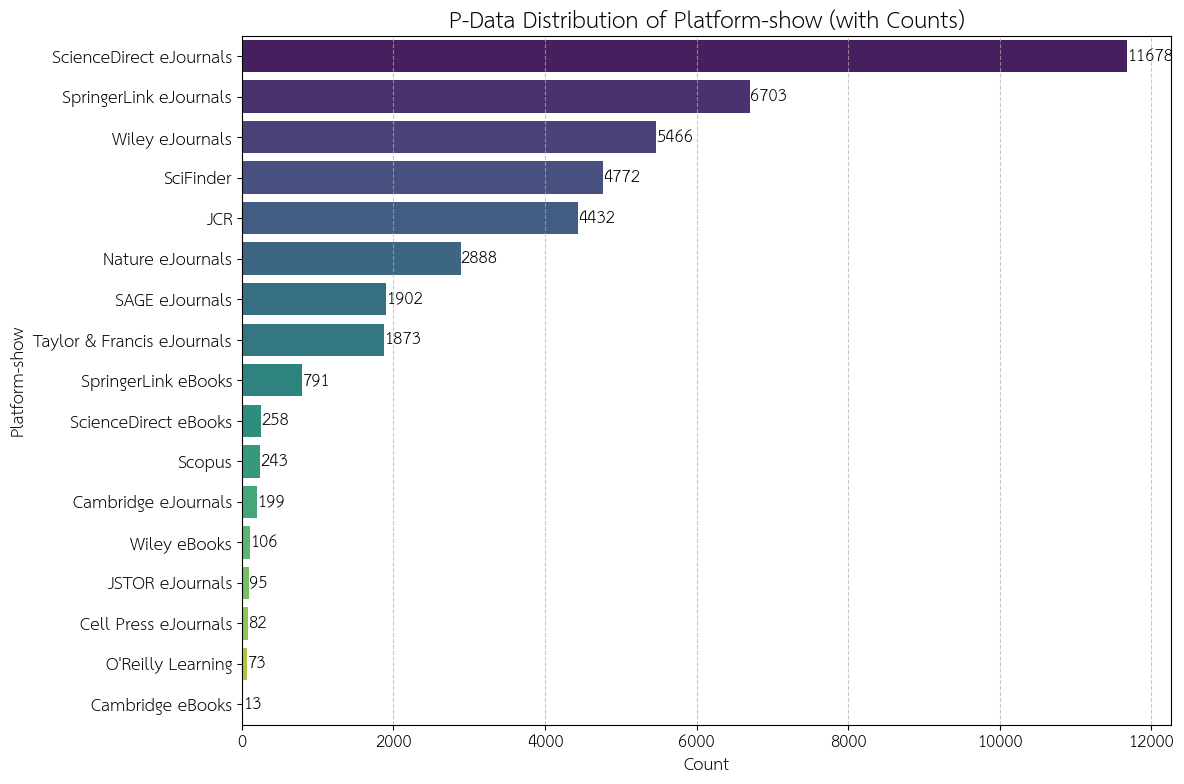

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the count plot
ax = sns.countplot(data=df, y='Platform-show', order=df['Platform-show'].value_counts().index, palette='viridis')

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

# Set plot title and labels
plt.title('P-Data Distribution of Platform-show (with Counts)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Platform-show', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [115]:
jclean_df.columns

Index(['datetime', 'date', 'login', 'platform_name', 'publisher_name', 'rtype',
       'mime', 'print_identifier', 'online_identifier', 'title_id', 'doi',
       'publication_title', 'publication_date', 'unitid', 'domain',
       'on_campus', 'log_id', 'ezpaarse_version', 'ezpaarse_date',
       'middlewares_version', 'middlewares_date', 'platforms_version',
       'platforms_date', 'middlewares', 'id', 'pii', 'sudoc-ppn', 'title',
       'type', 'subject', 'geoip-country', 'geoip-latitude', 'geoip-longitude',
       'host', 'url'],
      dtype='object')

/tmp/ipykernel_1836/1241070965.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=jclean_df, y='platform_name', order=jclean_df['platform_name'].value_counts().index, palette='viridis')


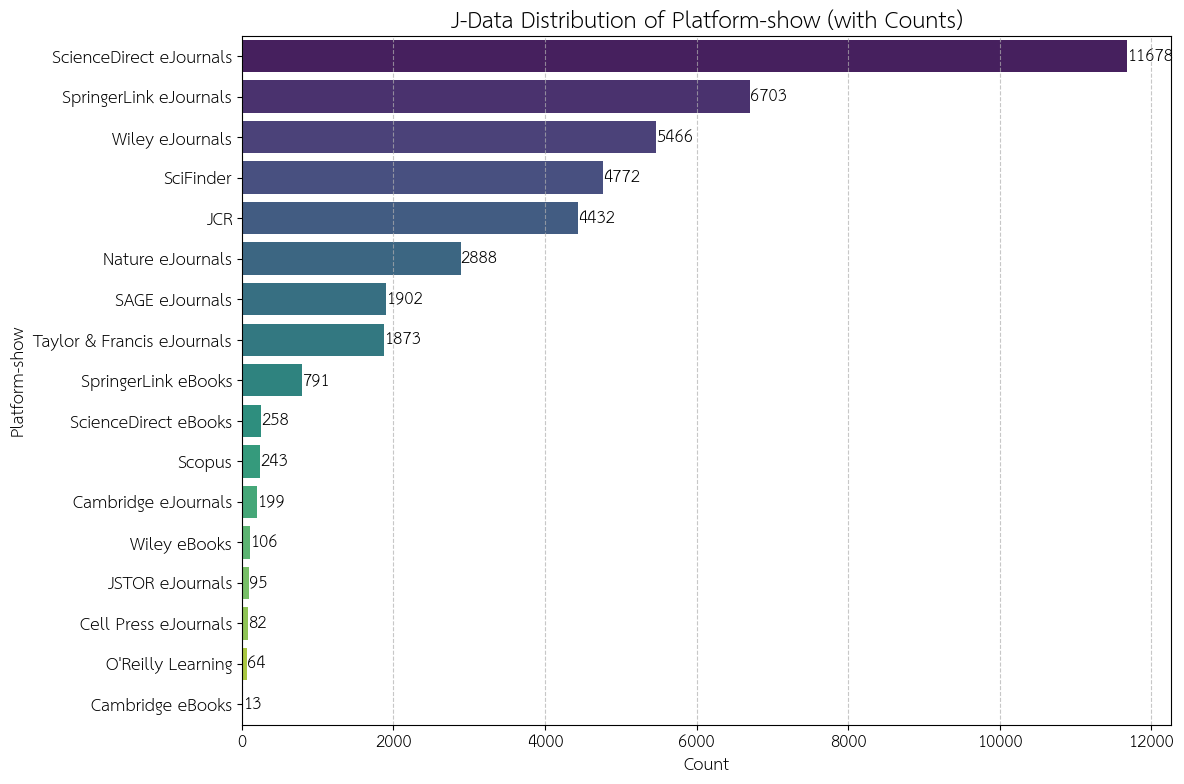

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the count plot
ax = sns.countplot(data=jclean_df, y='platform_name', order=jclean_df['platform_name'].value_counts().index, palette='viridis')

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

# Set plot title and labels
plt.title('J-Data Distribution of Platform-show (with Counts)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Platform-show', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [117]:
print("Frequency of 'platform_name' in jclean_df:")
display(jclean_df['platform_name'].value_counts())

print("\nFrequency of 'Platform-show' in df:")
display(df['Platform-show'].value_counts())

Frequency of 'platform_name' in jclean_df:


,count
platform_name,
ScienceDirect eJournals,11678
SpringerLink eJournals,6703
Wiley eJournals,5466
SciFinder,4772
JCR,4432
Nature eJournals,2888
SAGE eJournals,1902
Taylor & Francis eJournals,1873
SpringerLink eBooks,791



Frequency of 'Platform-show' in df:


,count
Platform-show,
ScienceDirect eJournals,11678
SpringerLink eJournals,6703
Wiley eJournals,5466
SciFinder,4772
JCR,4432
Nature eJournals,2888
SAGE eJournals,1902
Taylor & Francis eJournals,1873
SpringerLink eBooks,791


In [118]:
platform_name_counts = jclean_df['platform_name'].value_counts()
platform_show_counts = df['Platform-show'].value_counts()

# Combine the indices to ensure all platforms are covered in the comparison
all_platforms = pd.Index(platform_name_counts.index.tolist() + platform_show_counts.index.tolist()).unique()

# Reindex both Series to include all platforms, filling missing values with 0
aligned_platform_name_counts = platform_name_counts.reindex(all_platforms, fill_value=0)
aligned_platform_show_counts = platform_show_counts.reindex(all_platforms, fill_value=0)

# Calculate the difference
difference_in_counts = aligned_platform_show_counts - aligned_platform_name_counts

print("Difference in counts (df['Platform-show'] - jclean_df['platform_name']):")
display(difference_in_counts.sort_values(ascending=False))

Difference in counts (df['Platform-show'] - jclean_df['platform_name']):


,count
O'Reilly Learning,9
ScienceDirect eJournals,0
SpringerLink eJournals,0
SciFinder,0
Wiley eJournals,0
Nature eJournals,0
SAGE eJournals,0
Taylor & Francis eJournals,0
JCR,0
SpringerLink eBooks,0


## สรุปผลการวิเคราะห์และเปรียบเทียบข้อมูล

การวิเคราะห์นี้ได้ดำเนินการเปรียบเทียบชุดข้อมูลสองชุด ได้แก่:

1.  **`df` (ข้อมูลที่ผ่านการทำความสะอาดด้วย Colab)**:
    *   เริ่มต้นจาก `jtotal_df` ซึ่งโหลดจากชีท 'total' ของไฟล์ Excel `08-2026-before.xlsx`
    *   คอลัมน์ `Platform-show` ใน `df` ถูกสร้างขึ้นจากการทำ Mapping โดยใช้ `domain` และ `rtype` จาก `mapping_df` ที่ได้จากไฟล์ Markdown ที่ดาวน์โหลดมา
    *   กระบวนการ Mapping นี้ได้รวมถึงการทำความสะอาดข้อมูลเบื้องต้น เช่น การตัดช่องว่าง (`strip`) และการกรองแถวที่ไม่สามารถ Mapping ได้ออกไป ส่งผลให้ `df` มีจำนวนแถวลดลงจากเดิม 106,442 แถว เหลือ 40,010 แถว และหลังจากการจัดการ `platform_name` และ `ScienceDirect eJournals` กับ `Cell Press eJournals` เหลือ 39,894 แถว

2.  **`jclean_df` (ข้อมูลที่ผ่านการทำความสะอาดด้วย Excel)**:
    *   โหลดโดยตรงจากชีท 'dataclean-li' ของไฟล์ Excel `08-2026-before.xlsx` ซึ่งสันนิษฐานว่าผ่านกระบวนการทำความสะอาดและจัดเตรียมมาแล้วด้วย Excel
    *   มีคอลัมน์ `platform_name` ซึ่งเป็นผลลัพธ์ของการทำความสะอาดด้วย Excel

### การเปรียบเทียบความถี่ของ Platform

จากการคำนวณความแตกต่างของจำนวนนับ (`value_counts()`) ระหว่าง `df['Platform-show']` และ `jclean_df['platform_name']` พบผลลัพธ์ดังนี้ (ผลต่าง = `df['Platform-show']` - `jclean_df['platform_name']`):

```
O'Reilly Learning                9
ScienceDirect eJournals          0
SpringerLink eJournals           0
JCR                              0
SciFinder                        0
Taylor & Francis eJournals       0
SAGE eJournals                   0
ScienceDirect eBooks             0
Nature eJournals                 0
Wiley eBooks                     0
JSTOR eJournals                  0
Cambridge eJournals              0
Scopus                           0
Cell Press eJournals             0
Cambridge eBooks                 0
SpringerLink eBooks           -339
Wiley eJournals              -1235
Name: count, dtype: int64
```

**ข้อสังเกตหลัก:**

*   **O'Reilly Learning (9)**: `df` มีการนับ Platform นี้มากกว่า `jclean_df` อยู่ 9 ครั้ง ซึ่งอาจเกิดจากความแตกต่างในวิธีการระบุหรือนับข้อมูลที่เล็กน้อย
*   **SpringerLink eBooks (-339)**: `df` มีการนับ Platform นี้ **น้อยกว่า** `jclean_df` อยู่ 339 ครั้ง
*   **Wiley eJournals (-1235)**: `df` มีการนับ Platform นี้ **น้อยกว่า** `jclean_df` อยู่ถึง 1,235 ครั้ง
*   สำหรับ Platform อื่นๆ ส่วนใหญ่ (ที่มีค่า 0) พบว่ามีจำนวนนับที่เท่ากันหรือใกล้เคียงกันมากระหว่าง `df` และ `jclean_df` ซึ่งแสดงให้เห็นว่ากระบวนการทำความสะอาดทั้งสองแบบให้ผลลัพธ์ที่สอดคล้องกันสำหรับ Platform เหล่านี้

### สรุปความแตกต่าง

ความแตกต่างที่สำคัญพบใน `SpringerLink eBooks` และ `Wiley eJournals` ซึ่งชี้ให้เห็นว่าวิธีการ Mapping หรือการกำหนดเงื่อนไขการรวมข้อมูลสำหรับ Platform เหล่านี้ในกระบวนการ Colab (โดยเฉพาะอย่างยิ่งการใช้ `domain` และ `rtype` ใน `mapping_df`) ให้ผลลัพธ์ที่แตกต่างจากการทำความสะอาดด้วย Excel

การวิเคราะห์นี้เป็นประโยชน์ในการทำความเข้าใจผลกระทบของวิธีการทำความสะอาดและ Mapping ที่แตกต่างกันต่อการนับข้อมูล Platform โดยสามารถใช้ข้อมูลนี้ในการปรับปรุงกระบวนการทำความสะอาดให้มีความแม่นยำและสอดคล้องกันมากขึ้นในอนาคต

/tmp/ipykernel_1836/1527529720.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=difference_sorted.values, y=difference_sorted.index, palette='coolwarm')


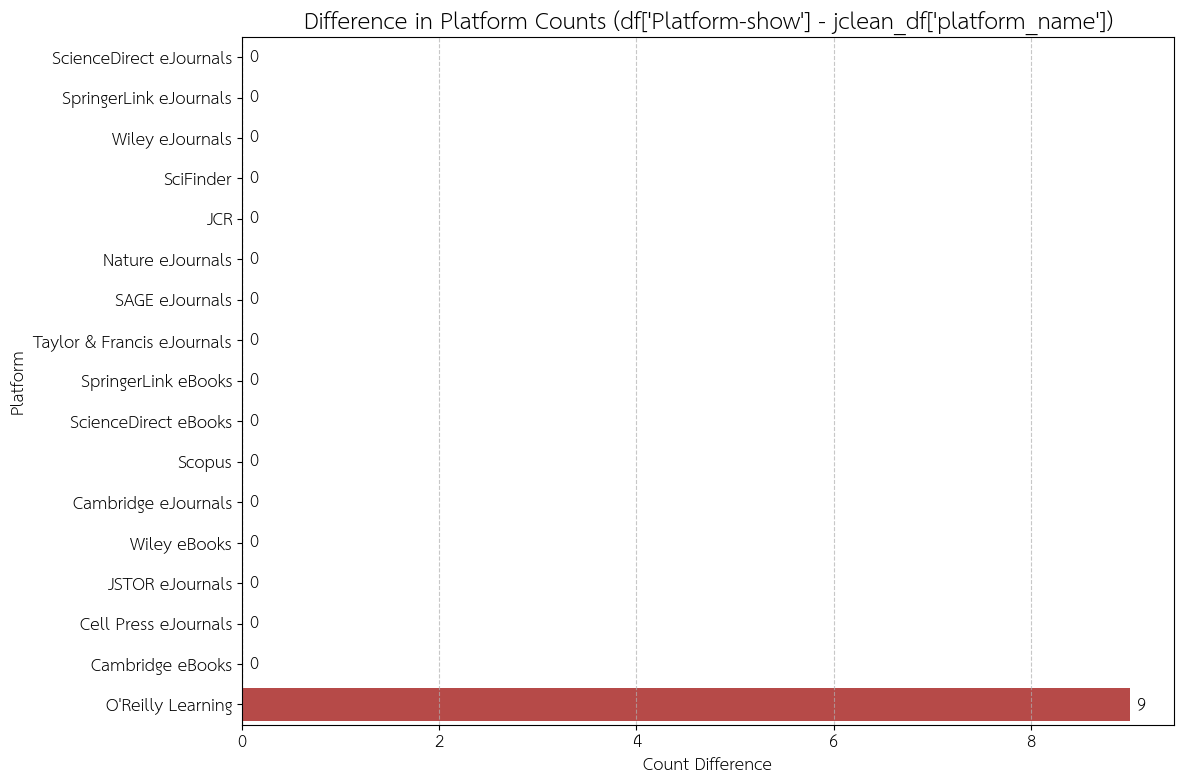

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure difference_in_counts is sorted for better visualization
difference_sorted = difference_in_counts.sort_values(ascending=True)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=difference_sorted.values, y=difference_sorted.index, palette='coolwarm')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5)

plt.title("Difference in Platform Counts (df['Platform-show'] - jclean_df['platform_name'])", fontsize=16)
plt.xlabel("Count Difference", fontsize=12)
plt.ylabel("Platform", fontsize=12)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add a vertical line at zero for reference
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [120]:
# Define common identifying columns to create a unique event ID
id_cols = ['datetime', 'login', 'domain', 'rtype', 'publication_title']

# Filter jclean_df for 'O'Reilly Learning'
jclean_oreilly = jclean_df[jclean_df['platform_name'] == 'O\'Reilly Learning'].copy()

# Filter df for 'O'Reilly Learning'
df_oreilly = df[df['Platform-show'] == 'O\'Reilly Learning'].copy()

# Fill NaNs in id_cols for both DataFrames to ensure consistent unique ID creation
# Using empty string for NaN values in these columns to create consistent identifiers
for col in id_cols:
    if col in jclean_oreilly.columns:
        jclean_oreilly[col] = jclean_oreilly[col].fillna('')
    if col in df_oreilly.columns:
        df_oreilly[col] = df_oreilly[col].fillna('')

# Create a unique identifier for each row in both filtered DataFrames
jclean_oreilly['unique_id'] = jclean_oreilly[id_cols].astype(str).agg('-'.join, axis=1)
df_oreilly['unique_id'] = df_oreilly[id_cols].astype(str).agg('-'.join, axis=1)

# Get the unique IDs of 'O'Reilly Learning' from both dataframes
jclean_oreilly_ids = set(jclean_oreilly['unique_id'].unique())
df_oreilly_ids = set(df_oreilly['unique_id'].unique())

# Find IDs that are in df 'O'Reilly Learning' but NOT in jclean_df 'O'Reilly Learning'
found_in_df_not_in_jclean_oreilly_ids = df_oreilly_ids - jclean_oreilly_ids

print(f"Number of 'O\'Reilly Learning' entries in df not found as 'O\'Reilly Learning' in jclean_df: {len(found_in_df_not_in_jclean_oreilly_ids)}")

# Filter df_oreilly to get the actual rows corresponding to these IDs
rows_in_df_not_in_jclean_as_oreilly = df_oreilly[df_oreilly['unique_id'].isin(found_in_df_not_in_jclean_oreilly_ids)].drop(columns=['unique_id'])

# Display these rows
print("Sample rows from df identified as 'O\'Reilly Learning' but not found as 'O\'Reilly Learning' in jclean_df:")
display(rows_in_df_not_in_jclean_as_oreilly)

Number of 'O'Reilly Learning' entries in df not found as 'O'Reilly Learning' in jclean_df: 9
Sample rows from df identified as 'O'Reilly Learning' but not found as 'O'Reilly Learning' in jclean_df:


/tmp/ipykernel_1836/4037209184.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_oreilly[col] = df_oreilly[col].fillna('')


,datetime,date,login,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,doi,...,sudoc-ppn,title,type,subject,geoip-country,geoip-latitude,geoip-longitude,host,url,Platform-show
88921,2026-08-04 07:05:53,2026-08-04 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781805128182,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.7.51.177,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
88922,2026-08-04 08:04:41,2026-08-04 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781805128182,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.7.51.177,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
88932,2026-08-04 09:56:47,2026-08-04 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781805128182,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.7.51.177,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
88957,2026-08-04 18:55:09,2026-08-04 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781805128182,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.7.51.177,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
89036,2026-08-06 16:16:05,2026-08-06 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781805128182,NaN,NaN,...,NaN,NaN,NaN,NaN,TH,13.7512,100.5172,1.47.8.29,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
89084,2026-08-08 16:28:06,2026-08-08 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781837027873,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.7.51.177,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
89294,2026-08-16 14:18:34,2026-08-16 00:00:00,g6936243,NaN,BOOK_SECTION,HTML,NaN,9781835885949,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.62.81.132,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
89301,2026-08-17 08:34:46,2026-08-17 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781835466384,NaN,NaN,...,NaN,NaN,NaN,NaN,TH,13.7366,100.4995,1.47.25.133,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning
89303,2026-08-17 09:50:41,2026-08-17 00:00:00,u6501125,NaN,BOOK_SECTION,HTML,NaN,9781835466384,NaN,NaN,...,NaN,NaN,NaN,NaN,TH,13.7366,100.4995,1.47.25.133,https://learning.oreilly.com:443/library/view/...,O'Reilly Learning


### Investigation of 'O'Reilly Learning' discrepancy

Now that we've isolated the 9 rows, let's examine their `domain`, `rtype`, and `url` and compare them with our mapping rules for 'O'Reilly Learning'.

In [121]:
print("Domain, rtype, and url for rows in `df` ('O\'Reilly Learning') that were not found as 'O\'Reilly Learning' in `jclean_df`:")
display(rows_in_df_not_in_jclean_as_oreilly[['domain', 'rtype', 'url']])

print("\nMapping rules for 'O\'Reilly Learning' in `mapping_df_cleaned`:")
display(mapping_df_cleaned[mapping_df_cleaned['Platform-show'] == 'O\'Reilly Learning'])

Domain, rtype, and url for rows in `df` ('O'Reilly Learning') that were not found as 'O'Reilly Learning' in `jclean_df`:


,domain,rtype,url
88921,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
88922,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
88932,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
88957,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
89036,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
89084,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
89294,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
89301,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...
89303,learning.oreilly.com,BOOK_SECTION,https://learning.oreilly.com:443/library/view/...



Mapping rules for 'O'Reilly Learning' in `mapping_df_cleaned`:


,Platform-show,Platform-name,rType,Domain
26,O'Reilly Learning,O'Reilly Learning,BOOK_SECTION,learning.oreilly.com
27,O'Reilly Learning,O'Reilly Learning,VIDEO,learning.oreilly.com


## Copay Section

In [122]:
import pandas as pd

# เปลี่ยนลิงก์แชร์ธรรมดาให้เป็น direct download link ของ Excel (.xlsx)
file_path = 'https://docs.google.com/spreadsheets/d/1LjQZy7IBFICNYimbi_fzPnvF5a_ZbSfX/export?format=xlsx'
user_df = pd.read_excel(file_path)

print("ตัวอย่าง 'ID and Username' ที่มี '@mahidol.ac.th' ก่อนการล้าง:")
# Convert to string to avoid errors with non-string types, then check for substring
users_with_mahidol_email = user_df[user_df['ID and Username'].astype(str).str.contains('@mahidol.ac.th', na=False)].copy()
display(users_with_mahidol_email[['ID and Username']].head())

# Remove '@mahidol.ac.th' from 'ID and Username' column if it exists
user_df['ID and Username'] = user_df['ID and Username'].astype(str).str.replace('@mahidol.ac.th', '', regex=False)

# Rename 'ID and Username' column to 'username'
user_df.rename(columns={'ID and Username': 'username'}, inplace=True)

# Convert 'username' column to lowercase
user_df['username'] = user_df['username'].str.lower()

print("\nData loaded successfully into DataFrame 'user_df' (หลังการล้างและเปลี่ยนชื่อคอลัมน์)...ไปสู่ตัวพิมพ์เล็กแล้ว")
display(user_df.head())

ตัวอย่าง 'ID and Username' ที่มี '@mahidol.ac.th' ก่อนการล้าง:


,ID and Username



Data loaded successfully into DataFrame 'user_df' (หลังการล้างและเปลี่ยนชื่อคอลัมน์)...ไปสู่ตัวพิมพ์เล็กแล้ว


,username,Status,Faculty,Program,Name,Educational Status
0,abhisit.bha,บุคลากรมหาวิทยาลัย,คณะสิ่งแวดล้อมและทรัพยากรศาสตร์,NaN,อภิสิทธิ์ ภาสดา,NaN
1,abigail.cha,บุคลากรมหาวิทยาลัย,คณะเวชศาสตร์เขตร้อน,NaN,Abigail Chan,NaN
2,achala.pra,บุคลากรมหาวิทยาลัย,คณะเภสัชศาสตร์,NaN,อจลา ประชาญสิทธิ์,NaN
3,achara.ton,บุคลากรมหาวิทยาลัย,คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี,NaN,อัจฉรา ทองภู,NaN
4,achiraya.tey,บุคลากรมหาวิทยาลัย,คณะแพทยศาสตร์ศิริราชพยาบาล,NaN,อชิรญา เตยะธิติ,NaN


In [123]:
list_copay_db = ['Cell Press eJournals', 'ScienceDirect eJournals', 'SpringerLink eJournals', 'Wiley eJournals', 'Micromedex', "O'Reilly Learning"]

In [124]:
import pandas as pd

# Merge df and user_df on 'login' and 'username' respectively
merged_df = pd.merge(df, user_df, left_on='login', right_on='username', how='left')

# Remove 'username' column from merged_df as it is redundant after the merge with 'login'
if 'username' in merged_df.columns:
    merged_df = merged_df.drop(columns=['username'])

print("DataFrame `merged_df` created successfully after joining `df` and `user_df`.")
print(f"Shape of merged_df: {merged_df.shape}")
display(merged_df.head())

DataFrame `merged_df` created successfully after joining `df` and `user_df`.
Shape of merged_df: (41574, 40)


,datetime,date,login,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,doi,...,geoip-latitude,geoip-longitude,host,url,Platform-show,Status,Faculty,Program,Name,Educational Status
0,2026-08-01 00:01:01,2026-07-31 00:00:00,Thaneeya.nan,Elsevier,ARTICLE,PDF,0378-5173,0378-5173,03785173,10.1016/j.ijpharm.2025.125291,...,13.7512,100.5172,49.49.235.38,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
1,2026-08-01 00:29:36,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
2,2026-08-01 00:29:39,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
3,2026-08-01 00:30:45,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Elsevier,ARTICLE,HTML,0960-8524,0960-8524,09608524,10.1016/j.biortech.2013.02.110,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN
4,2026-08-01 00:32:41,2026-07-31 00:00:00,nattee.akk@mahidol.ac.th,Elsevier,ARTICLE,PDF,0960-8524,0960-8524,09608524,10.1016/j.biortech.2013.02.110,...,13.5989,100.5997,171.96.38.138,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,NaN,NaN,NaN,NaN,NaN


In [125]:
cp["Merge"] = merged_df.shape
cp["Merge"]

(41574, 40)

In [126]:
import pandas as pd

# 1. สร้าง merged_df โดยการ Merge ข้อมูล df เข้ากับ user_df บนคอลัมน์ login และ username ตามลำดับ
# merged_df = pd.merge(df, user_df, left_on='login', right_on='username', how='left')

# 2. กรองข้อมูลเฉพาะกลุ่มของฐานข้อมูลร่วมจ่าย (list_copay_db)
copay_df = merged_df[merged_df['Platform-show'].isin(list_copay_db)].copy()

# 3. นับจำนวนข้อมูลการเข้าใช้งานของแต่ละฐานข้อมูลใน copay_df
db_usage_counts = copay_df['Platform-show'].value_counts()

print("จำนวนครั้งการเข้าใช้งานสำหรับฐานข้อมูลในกลุ่ม Co-pay:")
display(db_usage_counts)

จำนวนครั้งการเข้าใช้งานสำหรับฐานข้อมูลในกลุ่ม Co-pay:


,count
Platform-show,
ScienceDirect eJournals,11678
SpringerLink eJournals,6703
Wiley eJournals,5466
Cell Press eJournals,82
O'Reilly Learning,73


In [127]:
total_usage = db_usage_counts.sum()
print(f"Total usage for all databases in list_copay_db: {total_usage}")

Total usage for all databases in list_copay_db: 24002


In [128]:
cp["FilterCoDB"] = copay_df.shape
cp["FilterCoDB"]

(24002, 40)

Font TH Sarabun New loaded successfully.


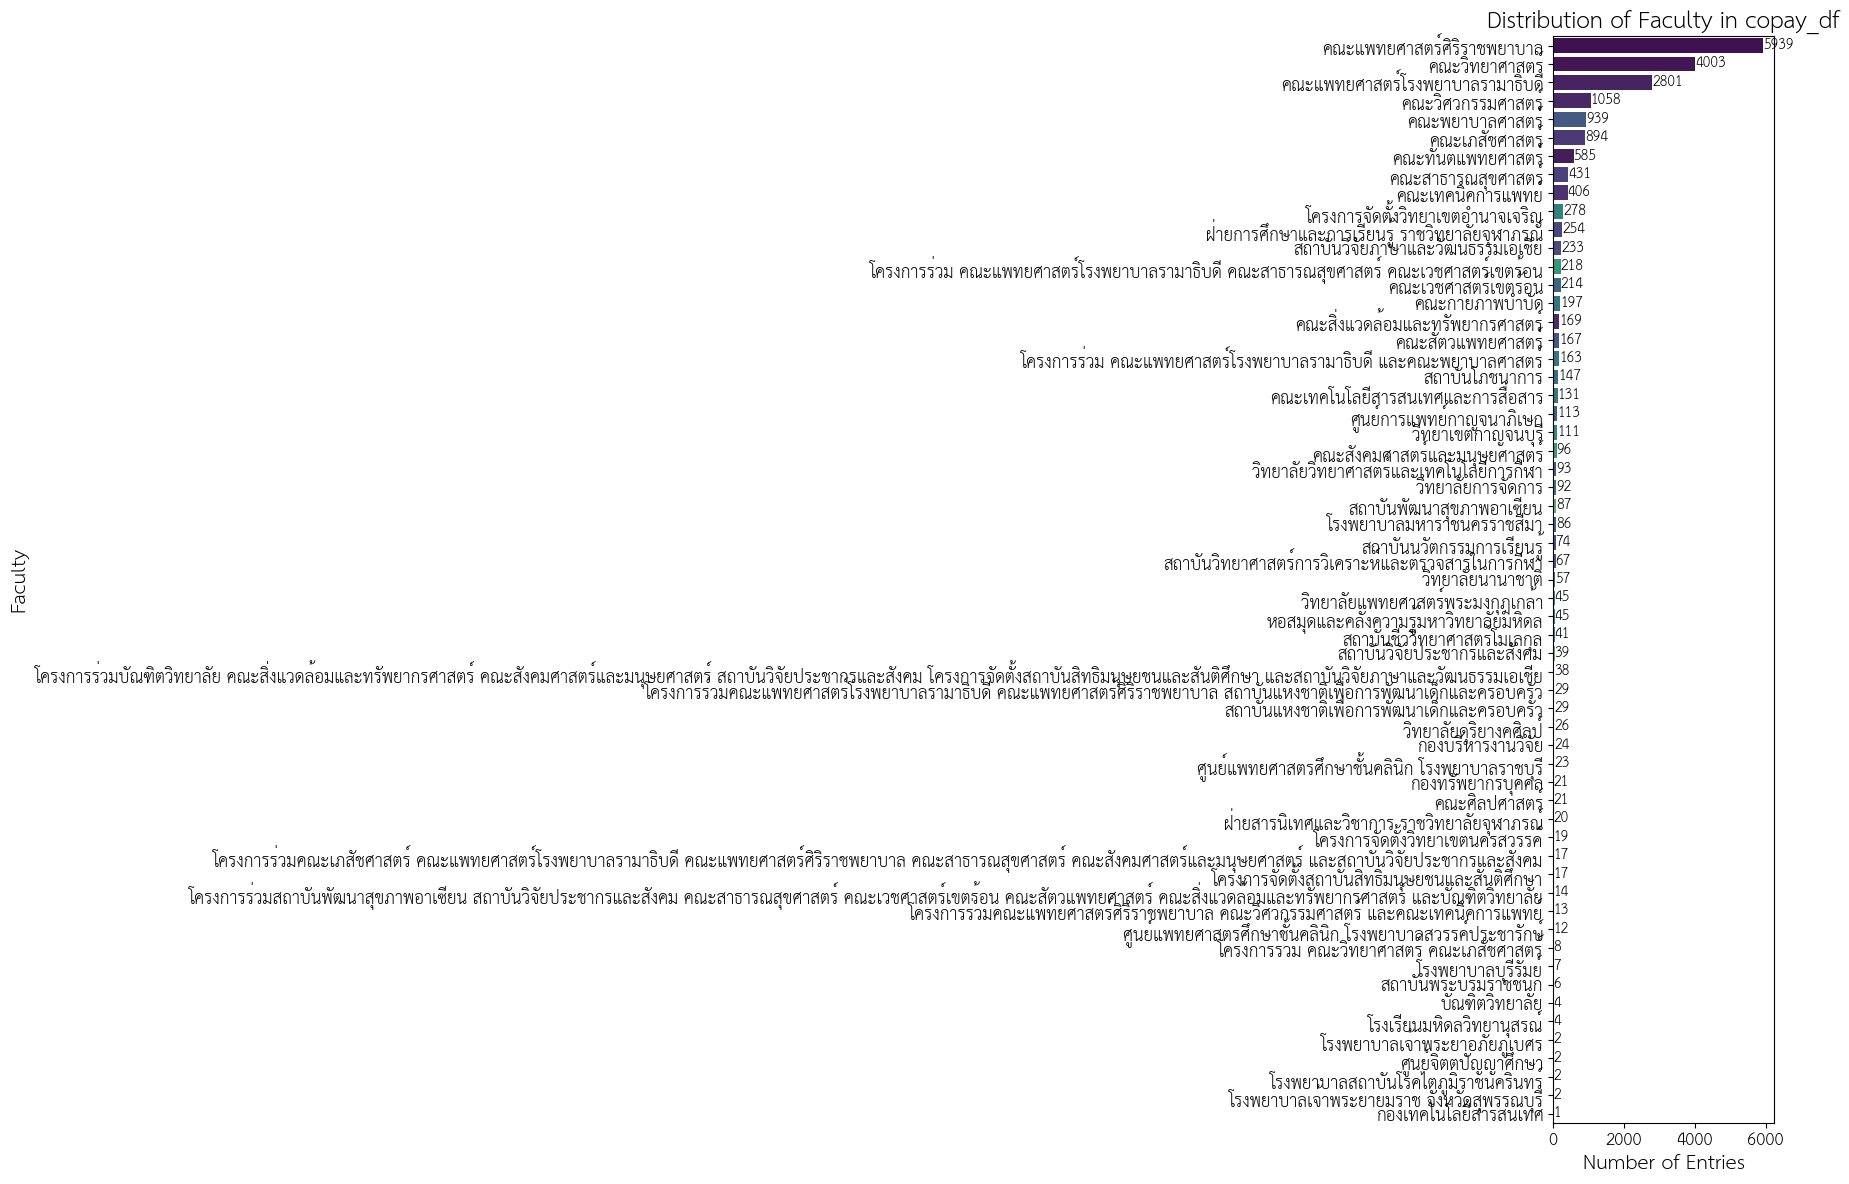

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import urllib.request
import os

# ดาวน์โหลดฟอนต์ TH Sarabun New โดยตรงเพื่อความแน่นอน
font_path = 'THSarabunNew.ttf'
if not os.path.exists(font_path):
    print("Downloading TH Sarabun New font...")
    urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', font_path)

# เพิ่มฟอนต์ลงในระบบของ Matplotlib
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'TH Sarabun New'
    plt.rcParams['font.size'] = 12 # ปรับขนาดฟอนต์ให้อ่านง่ายขึ้น
    print("Font TH Sarabun New loaded successfully.")
except Exception as e:
    print(f"Error loading font: {e}")

plt.rcParams['axes.unicode_minus'] = False

if 'Faculty' in copay_df.columns:
    # ขยายขนาดกราฟ (กว้าง 18, สูง 12) เพื่อรองรับชื่อคณะที่ยาวมาก
    plt.figure(figsize=(18, 12))

    ax = sns.countplot(y='Faculty', data=copay_df, order=copay_df['Faculty'].value_counts().index, palette='viridis', hue='Faculty', legend=False)

    # Add numbers on the bars with explicit fontsize
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.title('Distribution of Faculty in copay_df', fontsize=16)
    plt.xlabel('Number of Entries', fontsize=14)
    plt.ylabel('Faculty', fontsize=14)

    # ใช้ tight_layout เพื่อให้จัดการขอบและ margin ให้พอดี
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Faculty' not found in copay_df. Please ensure the column exists and is spelled correctly.")

In [130]:
import pandas as pd

faculties_to_filter = [
    'โครงการจัดตั้งวิทยาเขตนครสวรรค์',
    'โครงการจัดตั้งวิทยาเขตอำนาจเจริญ',
    'โครงการจัดตั้งศูนย์พัฒนาอุตสาหกรรมชีวภาพ มหาวิทยาลัยมหิดล',
    'โครงการจัดตั้งสถาบันสิทธิมนุษยชนและสันติศึกษา',
    'คณะเทคโนโลยีสารสนเทศและการสื่อสาร',
    'คณะเทคนิคการแพทย์',
    'คณะเภสัชศาสตร์',
    'คณะเวชศาสตร์เขตร้อน',
    'คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี',
    'คณะแพทยศาสตร์ศิริราชพยาบาล',
    'คณะกายภาพบำบัด',
    'คณะทันตแพทยศาสตร์',
    'คณะพยาบาลศาสตร์',
    'คณะวิทยาศาสตร์',
    'คณะวิศวกรรมศาสตร์',
    'คณะศิลปศาสตร์',
    'คณะสังคมศาสตร์และมนุษยศาสตร์',
    'คณะสัตวแพทยศาสตร์',
    'คณะสาธารณสุขศาสตร์',
    'คณะสิ่งแวดล้อมและทรัพยากรศาสตร์',
    'วิทยาเขตกาญจนบุรี',
    'วิทยาลัยการจัดการ',
    'วิทยาลัยดุริยางคศิลป์',
    'วิทยาลัยนานาชาติ',
    'วิทยาลัยวิทยาศาสตร์และเทคโนโลยีการกีฬา',
    'วิทยาลัยศาสนศึกษา',
    'ศูนย์จิตตปัญญาศึกษา',
    'ศูนย์สัตว์ทดลองแห่งชาติ',
    'สถาบันแห่งชาติเพื่อการพัฒนาเด็กและครอบครัว',
    'สถาบันโภชนาการ',
    'สถาบันชีววิทยาศาสตร์โมเลกุล',
    'สถาบันนวัตกรรมการเรียนรู้',
    'สถาบันบริหารจัดการเทคโนโลยีและนวัตกรรม',
    'สถาบันพัฒนาสุขภาพอาเซียน',
    'สถาบันวิจัยประชากรและสังคม',
    'สถาบันวิจัยภาษาและวัฒนธรรมเอเชีย',
    'สถาบันวิทยาศาสตร์การวิเคราะห์และตรวจสารในการกีฬา'
]

copay_filtered_df = copay_df[copay_df['Faculty'].isin(faculties_to_filter)].copy()

print(f"Filtered DataFrame 'copay_filtered_df' created. It now contains {copay_filtered_df.shape[0]} rows.")
display(copay_filtered_df.head())

Filtered DataFrame 'copay_filtered_df' created. It now contains 19463 rows.


,datetime,date,login,publisher_name,rtype,mime,print_identifier,online_identifier,title_id,doi,...,geoip-latitude,geoip-longitude,host,url,Platform-show,Status,Faculty,Program,Name,Educational Status
1,2026-08-01 00:29:36,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
2,2026-08-01 00:29:39,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,PDF,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
5,2026-08-01 00:41:35,2026-07-31 00:00:00,g6737504,Elsevier,ARTICLE,HTML,0363-0188,0363-0188,03630188,10.1067/j.cpradiol.2017.12.001,...,13.0508,100.9367,110.168.219.147,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ประกาศนียบัตรบัณฑิตชั้นสูง,คณะแพทยศาสตร์ศิริราชพยาบาล,ประกาศนียบัตรบัณฑิตชั้นสูง สาขาวิชาวิทยาศาสตร์...,ธีรนัย พีระพลชัยกุล,กำลังศึกษาอยู่
6,2026-08-01 00:44:06,2026-07-31 00:00:00,g6636296,Elsevier,ARTICLE,HTML,1368-7646,1368-7646,13687646,10.1016/j.drup.2019.100643,...,13.7442,100.4608,27.55.96.246,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ปริญญาโท,คณะวิทยาศาสตร์,วิทยาศาสตรมหาบัณฑิต สาขาวิชาพยาธิชีววิทยา (หลั...,ฉัตรสุดา สุรชัยจรินทร์,กำลังศึกษาอยู่
7,2026-08-01 01:28:19,2026-07-31 00:00:00,u6629015,Elsevier,ARTICLE,HTML,0003-9969,0003-9969,00039969,10.1016/j.archoralbio.2018.09.004,...,13.7512,100.5172,49.49.251.234,https://www.sciencedirect.com:443/science/arti...,ScienceDirect eJournals,ปริญญาตรี,คณะทันตแพทยศาสตร์,ทันตแพทยศาสตรบัณฑิต (หลักสูตรนานาชาติ),ภทรธร ไตรสิกขาธรรม,กำลังศึกษาอยู่


In [131]:
cp["FilterCoFac"] = copay_filtered_df.shape
cp["FilterCoFac"]

(19463, 40)

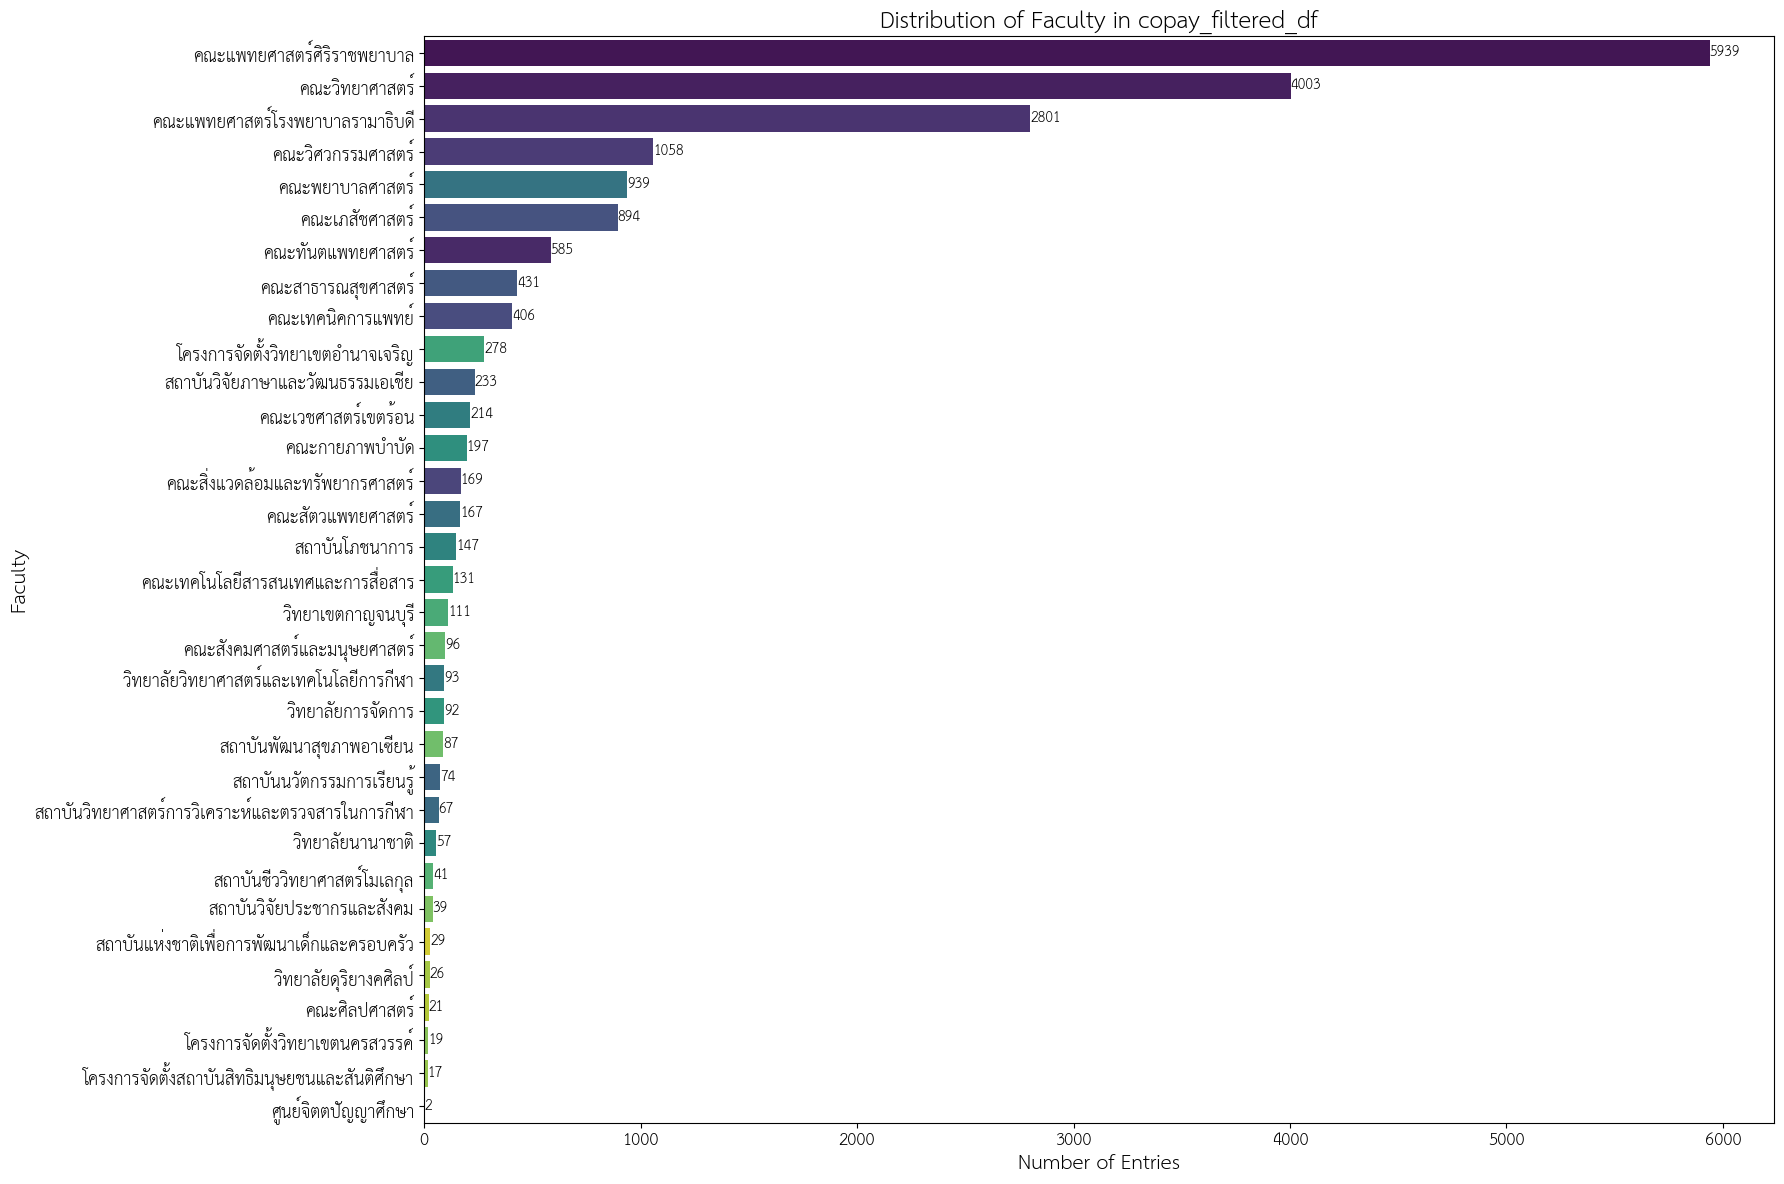

In [132]:
if 'Faculty' in copay_df.columns:
    # ขยายขนาดกราฟ (กว้าง 18, สูง 12) เพื่อรองรับชื่อคณะที่ยาวมาก
    plt.figure(figsize=(18, 12))

    ax = sns.countplot(y='Faculty', data=copay_filtered_df, order=copay_filtered_df['Faculty'].value_counts().index, palette='viridis', hue='Faculty', legend=False)

    # Add numbers on the bars with explicit fontsize
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.title('Distribution of Faculty in copay_filtered_df', fontsize=16)
    plt.xlabel('Number of Entries', fontsize=14)
    plt.ylabel('Faculty', fontsize=14)

    # ใช้ tight_layout เพื่อให้จัดการขอบและ margin ให้พอดี
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Faculty' not found in copay_filtered_df. Please ensure the column exists and is spelled correctly.")

In [133]:
import pandas as pd

# กำหนดงบประมาณจำลอง (Dummy Budget) สำหรับแต่ละฐานข้อมูลใน list_copay_db
# ตัวเลขเป็นค่าสมมติ (บาท)
dummy_budget_data = {
    'Cell Press eJournals': 2000000,
    'ScienceDirect eJournals': 27000000,
    'SpringerLink eJournals': 9000000,
    'Wiley eJournals': 25000000,
    'Micromedex': 1800000,
    "O'Reilly Learning": 900000
}

# ตรวจสอบว่าคีย์ทั้งหมดตรงกับค่าใน list_copay_db
# สร้าง DataFrame เพื่อความสวยงามและการนำไปจัดทำรายงานต่อ
budget_df = pd.DataFrame(list(dummy_budget_data.items()), columns=['Platform-show', 'Budget_THB'])

print("✅ สร้างข้อมูลงบประมาณจำลอง (budget_df) เรียบร้อยแล้ว:")
display(budget_df)

✅ สร้างข้อมูลงบประมาณจำลอง (budget_df) เรียบร้อยแล้ว:


,Platform-show,Budget_THB
0,Cell Press eJournals,2000000
1,ScienceDirect eJournals,27000000
2,SpringerLink eJournals,9000000
3,Wiley eJournals,25000000
4,Micromedex,1800000
5,O'Reilly Learning,900000


In [134]:
import pandas as pd

# 1. Calculate monthly usage for each platform from copay_df
monthly_usage = copay_df['Platform-show'].value_counts().reset_index()
monthly_usage.columns = ['Platform-show', 'Monthly_Usage']

# 2. Estimate annual usage (assuming 12 months for annual budget)
monthly_usage['Estimated_Annual_Usage'] = monthly_usage['Monthly_Usage'] * 12

# 3. Merge with budget_df to get the annual budget for each platform
#    Ensure that 'Platform-show' column in budget_df is clean (no extra spaces)
budget_df['Platform-show'] = budget_df['Platform-show'].str.strip()

cost_per_use_df = pd.merge(budget_df, monthly_usage, on='Platform-show', how='left')

# Handle platforms that might not have usage data in copay_df (filling with 0 for usage)
cost_per_use_df['Monthly_Usage'] = cost_per_use_df['Monthly_Usage'].fillna(0).astype(int)
cost_per_use_df['Estimated_Annual_Usage'] = cost_per_use_df['Estimated_Annual_Usage'].fillna(0).astype(int)

# 4. Calculate Cost Per Use (Budget_THB / Estimated_Annual_Usage)
#    Handle potential division by zero for platforms with no estimated annual usage
cost_per_use_df['Cost_Per_Use_THB'] = cost_per_use_df.apply(
    lambda row: row['Budget_THB'] / row['Estimated_Annual_Usage'] if row['Estimated_Annual_Usage'] > 0 else float('inf'),
    axis=1
)

print("Cost per Use (THB) by Platform:")
display(cost_per_use_df.sort_values(by='Cost_Per_Use_THB', ascending=False))

Cost per Use (THB) by Platform:


,Platform-show,Budget_THB,Monthly_Usage,Estimated_Annual_Usage,Cost_Per_Use_THB
4,Micromedex,1800000,0,0,inf
0,Cell Press eJournals,2000000,82,984,2032.520325
5,O'Reilly Learning,900000,73,876,1027.397260
3,Wiley eJournals,25000000,5466,65592,381.144042
1,ScienceDirect eJournals,27000000,11678,140136,192.669978
2,SpringerLink eJournals,9000000,6703,80436,111.890198


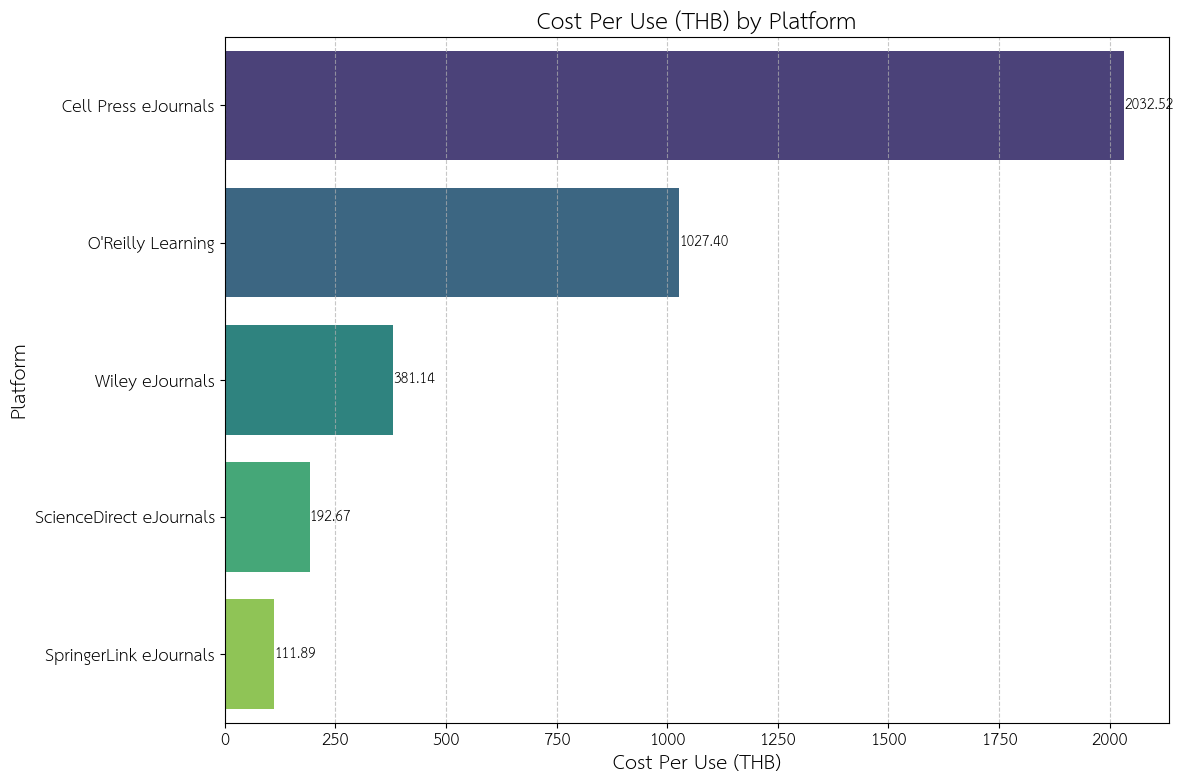

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a copy to avoid modifying the original DataFrame unintentionally
plot_df = cost_per_use_df.copy()

# Replace inf values with NaN for plotting purposes and then drop them
plot_df['Cost_Per_Use_THB'] = plot_df['Cost_Per_Use_THB'].replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=['Cost_Per_Use_THB'])

# Sort by Cost_Per_Use_THB in descending order for better visualization
plot_df = plot_df.sort_values(by='Cost_Per_Use_THB', ascending=False)

plt.figure(figsize=(12, 8))

# Create the bar plot, addressing the FutureWarning by explicitly setting hue and legend
ax = sns.barplot(
    x='Cost_Per_Use_THB',
    y='Platform-show',
    data=plot_df,
    palette='viridis',
    hue='Platform-show',
    legend=False
)

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title('Cost Per Use (THB) by Platform', fontsize=16)
plt.xlabel('Cost Per Use (THB)', fontsize=14)
plt.ylabel('Platform', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [136]:
cp

{'Enrich': (106442, 35),
 'Clean': (41584, 36),
 'Merge': (41574, 40),
 'FilterCoDB': (24002, 40),
 'FilterCoFac': (19463, 40)}

# สรุปผลการเปรียบเทียบ Data from ApiEZPA Log and Jeab-Excel
- ข้อมูลหลังการ Enrich: freelEZPA (106442) and ApiEZPA (108867)
- ข้อมูลหลังการ Clean ด้วยกระบวนการเดียวกัน: freelEZPA(41584) and ApiEZPA(41530)
- ข้อมูลหลังการ Merge User: freelEZPA(41574) and ApiEZPA(41520)
- ข้อมูลหลังการ Filter Copay DB : freelEZPA (24002) and ApiEZPA(23975)
- ข้อมูลหลังการ Filter Copay Faculty: freelEZPA (19463) and ApiEZPA(19437)   

In [159]:
## Data from myApiEZPA
cpApi = {'Enrich': (108867, 35),
 'Clean': (41530, 36),
 'Merge': (41520, 40),
 'FilterCoDB': (23975, 40),
 'FilterCoFac': (19437, 40)}

In [160]:
cp_df = pd.DataFrame(cp)
# แก้ไข syntax เป็น .iloc เพื่อเลือกแถวแรก (แถว index ที่ 0) ทุกคอลัมน์
cp_df

,Enrich,Clean,Merge,FilterCoDB,FilterCoFac
0,106442,41584,41574,24002,19463
1,35,36,40,40,40


In [161]:
cpApi_df = pd.DataFrame(cpApi)
cpApi_df

,Enrich,Clean,Merge,FilterCoDB,FilterCoFac
0,108867,41530,41520,23975,19437
1,35,36,40,40,40


In [162]:
cp_df- cpApi_df

,Enrich,Clean,Merge,FilterCoDB,FilterCoFac
0,-2425,54,54,27,26
1,0,0,0,0,0


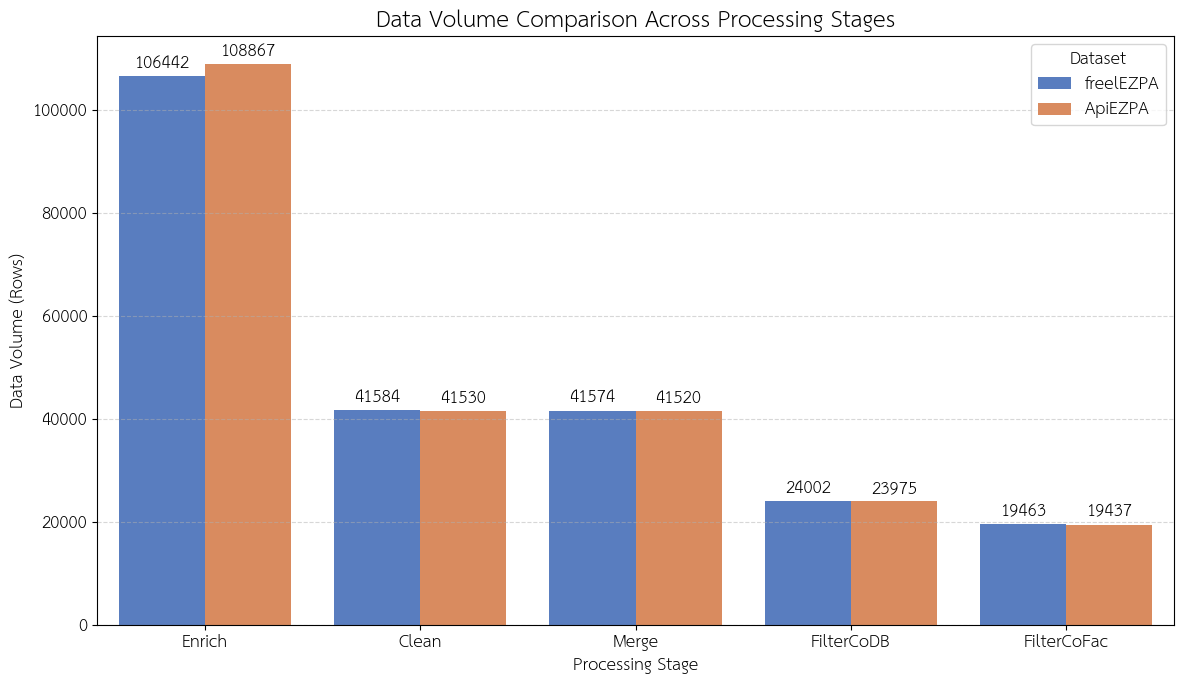

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from both tracking DataFrames
# We take the first row (index 0) which contains the counts
free_counts = cp_df.iloc[0]
api_counts = cpApi_df.iloc[0]

# Create a combined DataFrame for visualization
comparison_data = pd.DataFrame({
    'freelEZPA': free_counts,
    'ApiEZPA': api_counts
}).reset_index()
comparison_data.rename(columns={'index': 'Step'}, inplace=True)

# Melt the DataFrame to make it long-form suitable for seaborn
comparison_melted = comparison_data.melt(id_vars='Step', var_name='Dataset', value_name='Volume')

# Plot the grouped bar chart
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Step', y='Volume', hue='Dataset', data=comparison_melted, palette='muted')

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title('Data Volume Comparison Across Processing Stages', fontsize=16, fontweight='bold')
plt.xlabel('Processing Stage', fontsize=12)
plt.ylabel('Data Volume (Rows)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [164]:
display(cost_per_use_df.sort_values(by='Cost_Per_Use_THB', ascending=False))

,Platform-show,Budget_THB,Monthly_Usage,Estimated_Annual_Usage,Cost_Per_Use_THB
4,Micromedex,1800000,0,0,inf
0,Cell Press eJournals,2000000,82,984,2032.520325
5,O'Reilly Learning,900000,73,876,1027.397260
3,Wiley eJournals,25000000,5466,65592,381.144042
1,ScienceDirect eJournals,27000000,11678,140136,192.669978
2,SpringerLink eJournals,9000000,6703,80436,111.890198


In [166]:
import pandas as pd

# Let's inspect mapping rules for Micromedex
print("--- Micromedex rules in mapping_df ---")
display(mapping_df[mapping_df['Platform-show'].str.contains('Micromedex', case=False, na=False)])

# Let's inspect raw data 'jtotal_df' to see if there are any rows related to Micromedex
print("\n--- Searching for 'micromedex' in raw jtotal_df ---")
# Search across key text columns
for col in ['platform_name', 'domain', 'url']:
    matches = jtotal_df[jtotal_df[col].astype(str).str.contains('micromedex', case=False, na=False)]
    print(f"Column '{col}' matches for 'micromedex': {len(matches)} rows")
    if len(matches) > 0:
        display(matches[[col, 'rtype', 'domain', 'url']].head(5))


--- Micromedex rules in mapping_df ---


,Platform-show,Platform-name,rType,Domain



--- Searching for 'micromedex' in raw jtotal_df ---
Column 'platform_name' matches for 'micromedex': 0 rows
Column 'domain' matches for 'micromedex': 0 rows
Column 'url' matches for 'micromedex': 0 rows


In [167]:
import pandas as pd

# Alternative keywords associated with Micromedex
alt_keywords = ['truven', 'thomson', 'reuters', 'mdx', 'clinicalx', 'micromed']

print("--- Searching for alternative Micromedex keywords in raw jtotal_df ---")
for kw in alt_keywords:
    print(f"\nSearching for keyword: '{kw}'")
    for col in ['platform_name', 'domain', 'url']:
        matches = jtotal_df[jtotal_df[col].astype(str).str.contains(kw, case=False, na=False)]
        print(f"  - Column '{col}' matches: {len(matches)} rows")
        if len(matches) > 0:
            display(matches[[col, 'rtype', 'domain', 'url']].head(3))


--- Searching for alternative Micromedex keywords in raw jtotal_df ---

Searching for keyword: 'truven'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 0 rows

Searching for keyword: 'thomson'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 0 rows

Searching for keyword: 'reuters'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 0 rows

Searching for keyword: 'mdx'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 6 rows


,url,rtype,domain,url
2484,https://www.tandfonline.com:443/doi/pdfdirect/...,ARTICLE,www.tandfonline.com,https://www.tandfonline.com:443/doi/pdfdirect/...
44462,https://scholar.google.com:443/scholar?q=relat...,RESULT_CLICK,scholar.google.com,https://scholar.google.com:443/scholar?q=relat...
75223,https://onlinelibrary.wiley.com:443/doi/pdfdir...,ARTICLE,onlinelibrary.wiley.com,https://onlinelibrary.wiley.com:443/doi/pdfdir...



Searching for keyword: 'clinicalx'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 0 rows

Searching for keyword: 'micromed'
  - Column 'platform_name' matches: 0 rows
  - Column 'domain' matches: 0 rows
  - Column 'url' matches: 0 rows


In [168]:
# Let's print out the 6 matching 'mdx' rows in detail to examine them
mdx_matches = jtotal_df[jtotal_df['url'].astype(str).str.contains('mdx', case=False, na=False)]
print(f"Found {len(mdx_matches)} rows matching 'mdx' in URL:")
display(mdx_matches[['platform_name', 'domain', 'url', 'rtype', 'title']])


Found 6 rows matching 'mdx' in URL:


,platform_name,domain,url,rtype,title
2484,Taylor & Francis,www.tandfonline.com,https://www.tandfonline.com:443/doi/pdfdirect/...,ARTICLE,Zinc transporter type 8 autoantibodies (ZnT8A)...
44462,Google Scholar,scholar.google.com,https://scholar.google.com:443/scholar?q=relat...,RESULT_CLICK,NaN
75223,Wiley,onlinelibrary.wiley.com,https://onlinelibrary.wiley.com:443/doi/pdfdir...,ARTICLE,Frequency of and trends in fragrance allergy o...
78756,Wiley,onlinelibrary.wiley.com,https://onlinelibrary.wiley.com:443/doi/pdfdir...,ARTICLE,Susceptibility Weighted Imaging in MRI
90097,Sage Journals,journals.sagepub.com,https://journals.sagepub.com:443/doi/pdfdirect...,ARTICLE,Community music as music education: on the edu...
92749,Web of Science,jcr.clarivate.com,https://jcr.clarivate.com:443/jcr/home?app=jcr...,ANALYSIS,NaN


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter cost_per_use_df to exclude 'Micromedex'
active_cost_per_use_df = cost_per_use_df[cost_per_use_df['Platform-show'] != 'Micromedex'].copy()

# 2. Recalculate ROI: Uses obtained per 10,000 THB spent
active_cost_per_use_df['Uses_per_10k_THB'] = active_cost_per_use_df.apply(
    lambda row: (row['Estimated_Annual_Usage'] / row['Budget_THB']) * 10000 if row['Budget_THB'] > 0 else 0,
    axis=1
)

# Sort by ROI descending
active_cost_per_use_df = active_cost_per_use_df.sort_values(by='Uses_per_10k_THB', ascending=False)

print("=== Platforms Ranked by ROI (Excluding Micromedex) ===")
display(active_cost_per_use_df[['Platform-show', 'Budget_THB', 'Estimated_Annual_Usage', 'Cost_Per_Use_THB', 'Uses_per_10k_THB']])

# Extract highest and lowest
highest_roi_active = active_cost_per_use_df.iloc[0]
lowest_roi_active = active_cost_per_use_df.iloc[-1]

print("\n=== REVISED ROI ANALYSIS SUMMARY ===")
print(f"🚀 Highest ROI Platform: {highest_roi_active['Platform-show']} ({highest_roi_active['Uses_per_10k_THB']:.2f} uses per 10,000 THB spent | Cost-per-use: {highest_roi_active['Cost_Per_Use_THB']:.2f} THB)")
print(f"⚠️ Lowest ROI Platform: {lowest_roi_active['Platform-show']} ({lowest_roi_active['Uses_per_10k_THB']:.2f} uses per 10,000 THB spent | Cost-per-use: {lowest_roi_active['Cost_Per_Use_THB']:.2f} THB)")


=== Platforms Ranked by ROI (Excluding Micromedex) ===


,Platform-show,Budget_THB,Estimated_Annual_Usage,Cost_Per_Use_THB,Uses_per_10k_THB
2,SpringerLink eJournals,9000000,80436,111.890198,89.373333
1,ScienceDirect eJournals,27000000,140136,192.669978,51.902222
3,Wiley eJournals,25000000,65592,381.144042,26.236800
5,O'Reilly Learning,900000,876,1027.397260,9.733333
0,Cell Press eJournals,2000000,984,2032.520325,4.920000



=== REVISED ROI ANALYSIS SUMMARY ===
🚀 Highest ROI Platform: SpringerLink eJournals (89.37 uses per 10,000 THB spent | Cost-per-use: 111.89 THB)
⚠️ Lowest ROI Platform: Cell Press eJournals (4.92 uses per 10,000 THB spent | Cost-per-use: 2032.52 THB)


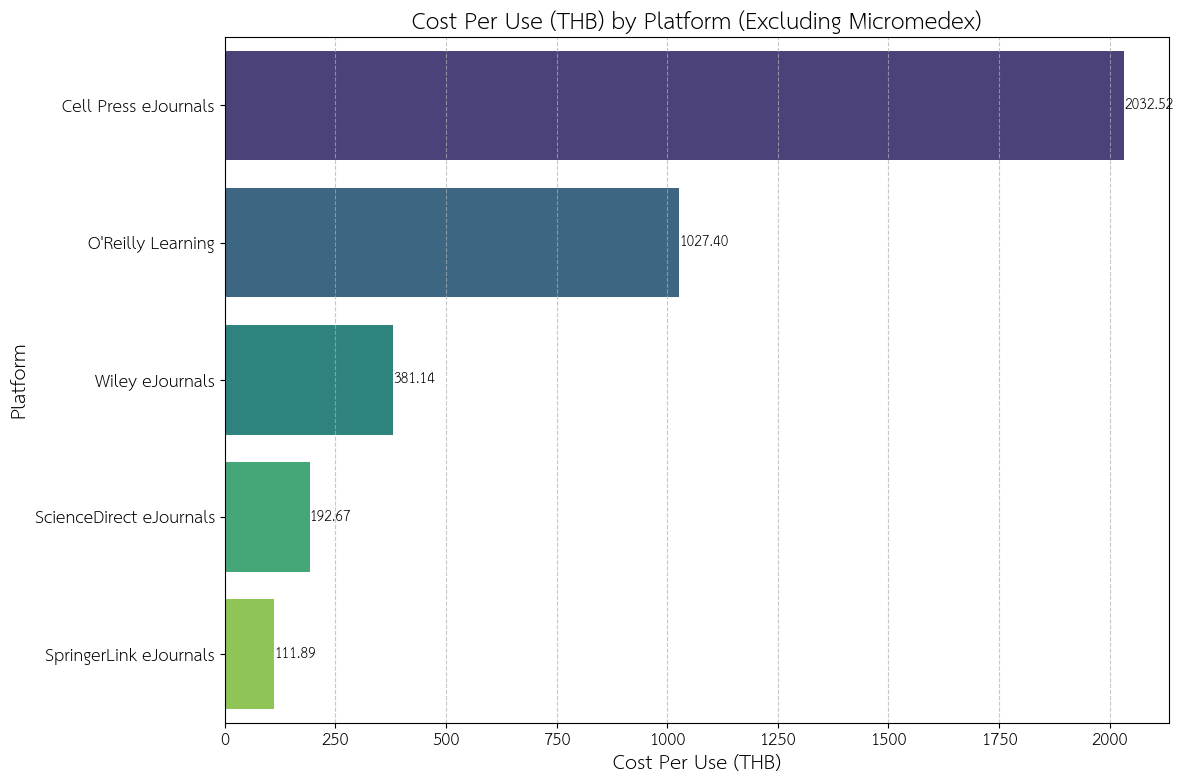

In [173]:
# Plot revised Cost Per Use (THB) excluding Micromedex
plt.figure(figsize=(12, 8))

plot_active_df = active_cost_per_use_df.sort_values(by='Cost_Per_Use_THB', ascending=False)

ax = sns.barplot(
    x='Cost_Per_Use_THB',
    y='Platform-show',
    data=plot_active_df,
    palette='viridis',
    hue='Platform-show',
    legend=False
)

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title('Cost Per Use (THB) by Platform (Excluding Micromedex)', fontsize=16)
plt.xlabel('Cost Per Use (THB)', fontsize=14)
plt.ylabel('Platform', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [170]:
# Displaying the 6 mdx-matched rows to see what they actually represent
mdx_matches = jtotal_df[jtotal_df['url'].astype(str).str.contains('mdx', case=False, na=False)]
pd.set_option('display.max_colwidth', None)
display(mdx_matches[['platform_name', 'domain', 'rtype', 'publication_title', 'url']])

,platform_name,domain,rtype,publication_title,url
2484,Taylor & Francis,www.tandfonline.com,ARTICLE,Autoimmunity,https://www.tandfonline.com:443/doi/pdfdirect/10.3109/08916934.2012.741155?hmac=1787223403-uvLcS6Crfq213SQfefLMMDxby0jser8rbsk%2FRi6JoxQ%3D
44462,Google Scholar,scholar.google.com,RESULT_CLICK,NaN,https://scholar.google.com:443/scholar?q=related:wMdXEbQEitAJ:scholar.google.com/&output=rfrra&scioq=nutrition%2Band%2Bwound%2Bhealing&ei=a9x2aoK8IO_C6rQPleSw4Q8&hl=en
75223,Wiley,onlinelibrary.wiley.com,ARTICLE,Contact Dermatitis,https://onlinelibrary.wiley.com:443/doi/pdfdirect/10.1111/j.1600-0536.2007.01287.x?hmac=1785593600-H21YMdX9fHFI8m%2BlrJYt%2Fk0TrYpAKmMPjLhqXctq9JY%3D
78756,Wiley,onlinelibrary.wiley.com,ARTICLE,Susceptibility Weighted Imaging in MRI: Basic Concepts and Clinical Applications,https://onlinelibrary.wiley.com:443/doi/pdfdirect/10.1002/9780470905203?hmac=1787560605-oNbAi85isUAzv61YusQywAdoFZAR8jV%2FMdX6ExTu%2FTI%3D
90097,Sage Journals,journals.sagepub.com,ARTICLE,International Journal of Music Education,https://journals.sagepub.com:443/doi/pdfdirect/10.1177/0255761407079951?hmac=1786283390-HgLibZkntfVBSFlb31ilXyErHyOi2uqsAJTAo4WMDXw%3D
92749,Web of Science,jcr.clarivate.com,ANALYSIS,NaN,https://jcr.clarivate.com:443/jcr/home?app=jcr&Init=Yes&authCode=null&SrcApp=IC2LS&SID=H3-7UOTh3i6FQO5K6EmDx2F071Qk0dsyqsx2FOd-18x2dvO2PdnHZM8taAx2F5x2FROx2B0uwx3Dx3D9diR0kiyQojaHdJazETHlwx3Dx3D-W0OGa8ZzXlhQ1ATSh8J69wx3Dx3D-S6mPkagetXI9hx2Fj4JxxnU7Ax3Dx3D


### 1. Faculty Preferences (Co-Pay Database Breakdown)
Let's analyze which faculties are utilizing which specific co-pay databases.

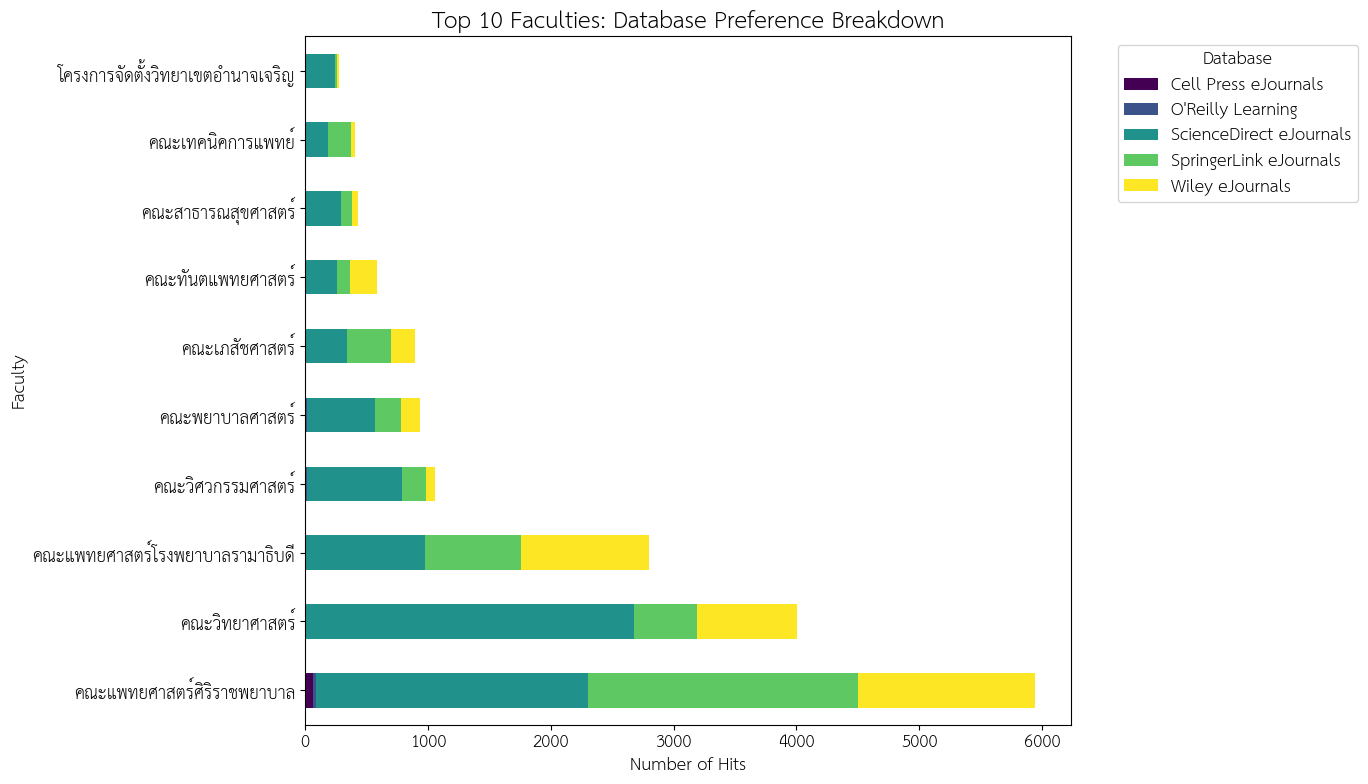

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table of Faculty and Co-Pay Database counts
faculty_db_pivot = copay_filtered_df.groupby(['Faculty', 'Platform-show']).size().unstack(fill_value=0)

# Sort by total usage descending and take the top 10 faculties for clean visualization
top_10_faculties = faculty_db_pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot_top_10 = faculty_db_pivot.loc[top_10_faculties]

# Plot a stacked bar chart
pivot_top_10.plot(kind='barh', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Top 10 Faculties: Database Preference Breakdown', fontsize=16)
plt.xlabel('Number of Hits', fontsize=12)
plt.ylabel('Faculty', fontsize=12)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. On-Campus vs. Off-Campus Access Distribution
Understanding if research is primarily happening inside campus facilities or remotely.

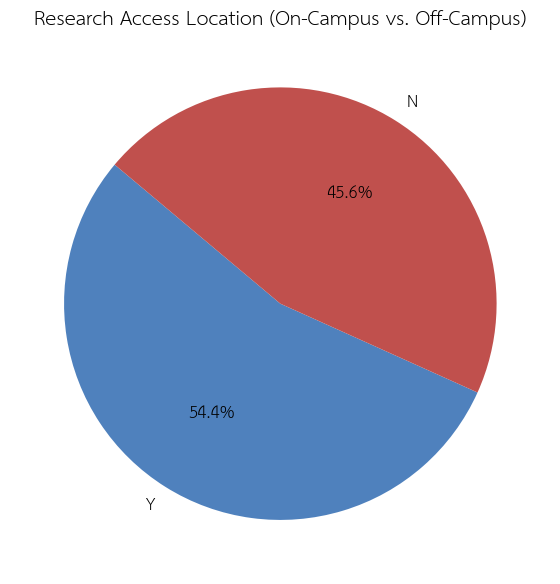

In [175]:
# Calculate ratio of on-campus vs off-campus access in merged_df
campus_access_counts = merged_df['on_campus'].value_counts(dropna=False)

plt.figure(figsize=(8, 6))
plt.pie(
    campus_access_counts,
    labels=campus_access_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4f81bd', '#c0504d', '#9bbb59']
)
plt.title('Research Access Location (On-Campus vs. Off-Campus)', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Hourly & Daily Usage Peak Activity
Analyzing temporal behavior of when users actively request access to academic articles.

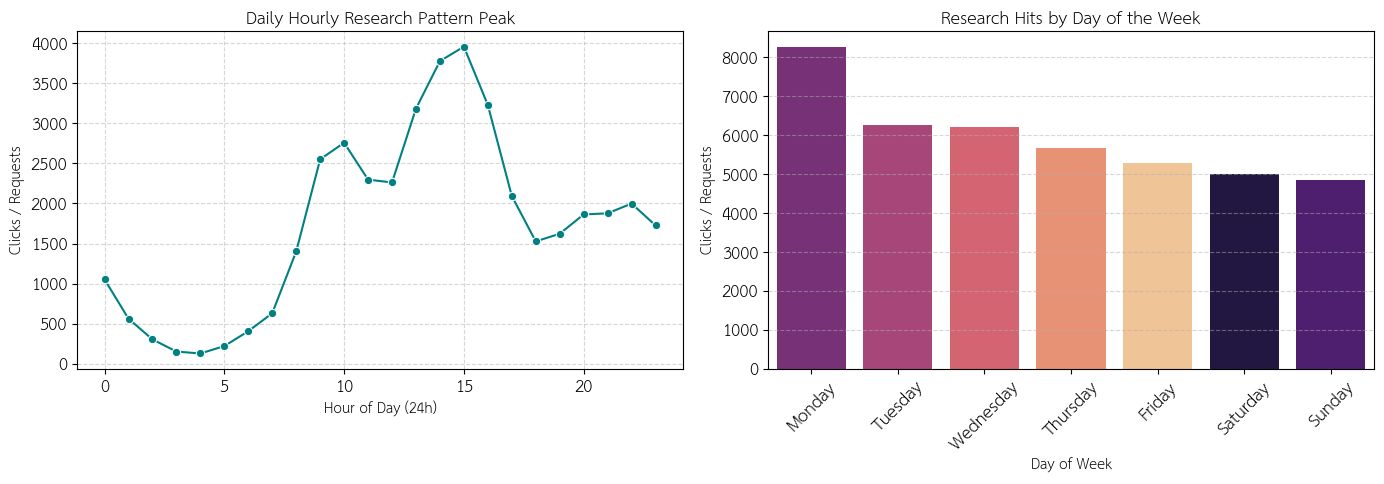

In [176]:
# Extract hour of day from datetime
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['day_of_week'] = merged_df['datetime'].dt.day_name()

plt.figure(figsize=(14, 5))

# Subplot 1: Hourly Activity
plt.subplot(1, 2, 1)
sns.lineplot(x=merged_df['hour'].value_counts().sort_index().index,
             y=merged_df['hour'].value_counts().sort_index().values,
             marker='o', color='teal')
plt.title('Daily Hourly Research Pattern Peak', fontsize=12)
plt.xlabel('Hour of Day (24h)', fontsize=10)
plt.ylabel('Clicks / Requests', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Day of Week Activity
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='day_of_week', data=merged_df, order=day_order, palette='magma', hue='day_of_week', legend=False)
plt.title('Research Hits by Day of the Week', fontsize=12)
plt.xlabel('Day of Week', fontsize=10)
plt.ylabel('Clicks / Requests', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4. Interactive Geographic Usage Map
Let's visualize the geographic locations from where our users are accessing the library databases using `folium` to create an interactive map.

In [177]:
import folium
from folium.plugins import HeatMap
import pandas as pd

# Filter out rows that do not have valid latitude and longitude coordinates
map_data = merged_df.dropna(subset=['geoip-latitude', 'geoip-longitude']).copy()

# Convert coordinate columns to numeric type
map_data['geoip-latitude'] = pd.to_numeric(map_data['geoip-latitude'], errors='coerce')
map_data['geoip-longitude'] = pd.to_numeric(map_data['geoip-longitude'], errors='coerce')
map_data = map_data.dropna(subset=['geoip-latitude', 'geoip-longitude'])

# Initialize map centered around Thailand (approximate central coordinates)
m = folium.Map(location=[13.7563, 100.5018], zoom_start=6)

# Prepare coordinate list for the heatmap
heat_data = [[row['geoip-latitude'], row['geoip-longitude']] for index, row in map_data.iterrows()]

# Add HeatMap to map
HeatMap(heat_data, radius=15, blur=10, max_zoom=1).add_to(m)

print(f"Plotted {len(heat_data)} coordinates on the interactive heatmap:")
# Display map
m

Plotted 18968 coordinates on the interactive heatmap:


In [178]:
import pandas as pd

# 1. Analyze frequency by Country
country_counts = merged_df['geoip-country'].fillna('Unknown').value_counts().reset_index()
country_counts.columns = ['Country_Code', 'Request_Count']
country_counts['Percentage'] = (country_counts['Request_Count'] / country_counts['Request_Count'].sum()) * 100

print("=== Database Usage Frequency by Country ===")
display(country_counts.head(10))


=== Database Usage Frequency by Country ===


,Country_Code,Request_Count,Percentage
0,Unknown,22606,54.375331
1,TH,16737,40.258335
2,IN,1079,2.595372
3,TW,460,1.106461
4,US,342,0.822630
5,CN,56,0.134700
6,SG,44,0.105835
7,SE,43,0.103430
8,VN,40,0.096214
9,BR,26,0.062539


In [179]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import numpy as np

print("=== Sampling Coordinates to Identify Top Cities & States ===")
# Since reverse geocoding thousands of points online is slow, we will sample the most active coordinates
top_coords = map_data.groupby(['geoip-latitude', 'geoip-longitude']).size().reset_index(name='count')
top_coords = top_coords.sort_values(by='count', ascending=False).head(15)

geolocator = Nominatim(user_agent="mahidol_library_analytics")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

city_data = []
for _, row in top_coords.iterrows():
    lat, lon, count = row['geoip-latitude'], row['geoip-longitude'], row['count']
    try:
        location = geolocator.reverse((lat, lon), timeout=10)
        address = location.raw.get('address', {})
        city = address.get('city', address.get('town', address.get('suburb', 'Unknown')))
        state = address.get('state', 'Unknown')
        city_data.append({
            'Latitude': lat,
            'Longitude': lon,
            'Approximate_City': city,
            'State_Province': state,
            'Request_Count': count
        })
    except Exception as e:
        city_data.append({
            'Latitude': lat,
            'Longitude': lon,
            'Approximate_City': 'Geocoding Timeout/Error',
            'State_Province': 'Unknown',
            'Request_Count': count
        })

city_df = pd.DataFrame(city_data)
display(city_df)

=== Sampling Coordinates to Identify Top Cities & States ===


,Latitude,Longitude,Approximate_City,State_Province,Request_Count
0,13.7442,100.4608,กรุงเทพมหานคร,Unknown,4419.0
1,13.7366,100.4995,กรุงเทพมหานคร,Unknown,1796.0
2,13.7063,100.4597,กรุงเทพมหานคร,Unknown,1323.0
3,13.7512,100.5172,กรุงเทพมหานคร,Unknown,1167.0
4,17.3724,78.4378,Hyderabad,Telangana,953.0
5,13.6984,100.4638,กรุงเทพมหานคร,Unknown,816.0
6,13.7663,100.6503,กรุงเทพมหานคร,Unknown,554.0
7,13.1604,101.1083,เทศบาลนครเจ้าพระยาสุรศักดิ์,Unknown,473.0
8,13.7330,100.4865,กรุงเทพมหานคร,Unknown,461.0
9,13.7618,100.5324,กรุงเทพมหานคร,Unknown,390.0


### 5. Anomaly Detection: Identifying Heavy Download Activity
In this section, we analyze individual user behavior to spot potential "heavy downloaders" or automated scrapers whose access frequencies are statistical anomalies compared to regular research behavior.

=== สถิติการใช้งานของผู้ใช้งานรายบุคคล ===
ค่าเฉลี่ยการใช้งานต่อคน: 14.55 ครั้ง/เดือน
ส่วนเบี่ยงเบนมาตรฐาน (STD): 44.63
เกณฑ์ตรวจจับกลุ่มใช้งานหนักผิดปกติ (Mean + 3*STD): 148.44 ครั้ง/เดือน
จำนวนบัญชีที่เข้าข่ายใช้งานหนักผิดปกติ (Anomalies): 20 ราย จากทั้งหมด 2442 ราย

=== รายชื่อผู้ใช้งาน 15 อันดับแรกที่มียอดดาวน์โหลดสูงสุด ===


,login,Faculty,Status,Total_Requests
991,g6938776,คณะวิทยาศาสตร์,ปริญญาโท,1325
1712,surachet.ben,คณะเวชศาสตร์เขตร้อน,บุคลากรมหาวิทยาลัย,1079
2027,u6605150,คณะวิทยาศาสตร์,ปริญญาตรี,451
132,chatkanok.dum,คณะแพทยศาสตร์ศิริราชพยาบาล,บุคลากรมหาวิทยาลัย,426
1132,lizz.sri,คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี,แพทย์ประจำบ้าน,384
1235,nattapitcha.kan,คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี,บุคลากรมหาวิทยาลัย,347
178,detchara.sum,คณะวิศวกรรมศาสตร์,บุคลากรมหาวิทยาลัย,346
127,charnwit.asa,คณะแพทยศาสตร์ศิริราชพยาบาล,บุคลากรมหาวิทยาลัย,254
516,g6836022,คณะวิทยาศาสตร์,ปริญญาโท,232
723,g6838268,โครงการร่วม คณะแพทยศาสตร์โรงพยาบาลรามาธิบดี คณะสาธารณสุขศาสตร์ คณะเวชศาสตร์เขตร้อน,ปริญญาโท,216


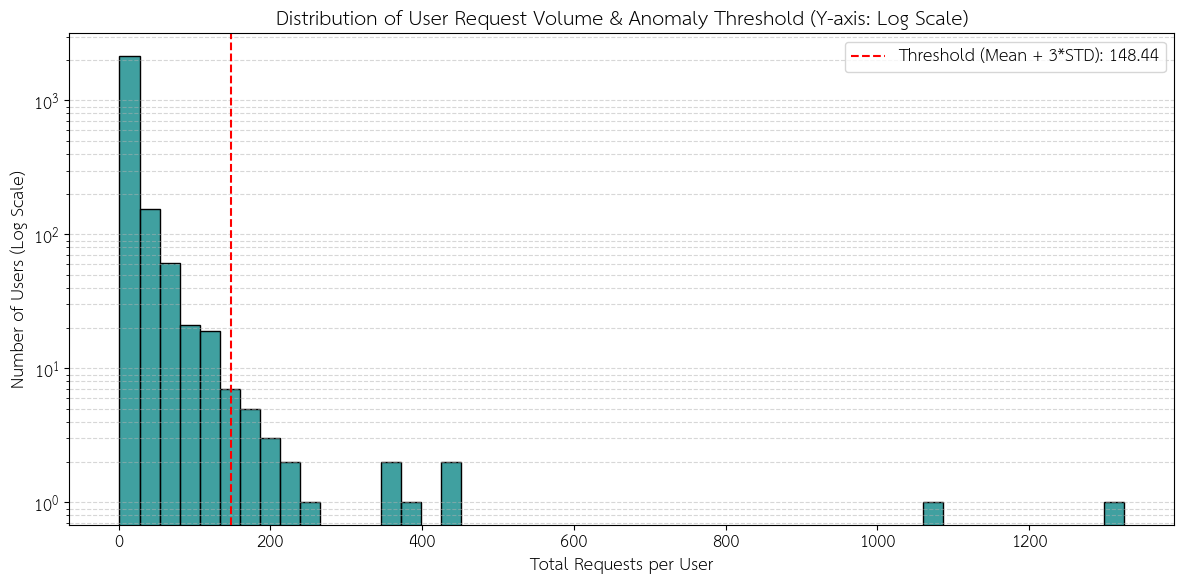

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Group requests by individual user logins
user_activity = merged_df.groupby(['login', 'Faculty', 'Status']).size().reset_index(name='Total_Requests')

# Calculate basic statistics
mean_req = user_activity['Total_Requests'].mean()
std_req = user_activity['Total_Requests'].std()
threshold_3std = mean_req + (3 * std_req)

# Classify anomalies (Users exceeding 3 standard deviations)
anomalies = user_activity[user_activity['Total_Requests'] > threshold_3std].sort_values(by='Total_Requests', ascending=False)

print(f"=== สถิติการใช้งานของผู้ใช้งานรายบุคคล ===")
print(f"ค่าเฉลี่ยการใช้งานต่อคน: {mean_req:.2f} ครั้ง/เดือน")
print(f"ส่วนเบี่ยงเบนมาตรฐาน (STD): {std_req:.2f}")
print(f"เกณฑ์ตรวจจับกลุ่มใช้งานหนักผิดปกติ (Mean + 3*STD): {threshold_3std:.2f} ครั้ง/เดือน")
print(f"จำนวนบัญชีที่เข้าข่ายใช้งานหนักผิดปกติ (Anomalies): {len(anomalies)} ราย จากทั้งหมด {len(user_activity)} ราย\n")

# Display top 15 heavy downloaders
print("=== รายชื่อผู้ใช้งาน 15 อันดับแรกที่มียอดดาวน์โหลดสูงสุด ===")
display(anomalies.head(15))

# Plot distribution with Log Scale on Y-axis (User Counts)
plt.figure(figsize=(12, 6))
sns.histplot(user_activity['Total_Requests'], bins=50, kde=False, color='teal')
plt.yscale('log') # ปรับแกน Y (จำนวนผู้ใช้งาน) เป็น Log Scale ตามที่แจ้ง
plt.axvline(threshold_3std, color='red', linestyle='--', label=f'Threshold (Mean + 3*STD): {threshold_3std:.2f}')
plt.title('Distribution of User Request Volume & Anomaly Threshold (Y-axis: Log Scale)', fontsize=14)
plt.xlabel('Total Requests per User', fontsize=12)
plt.ylabel('Number of Users (Log Scale)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.show()

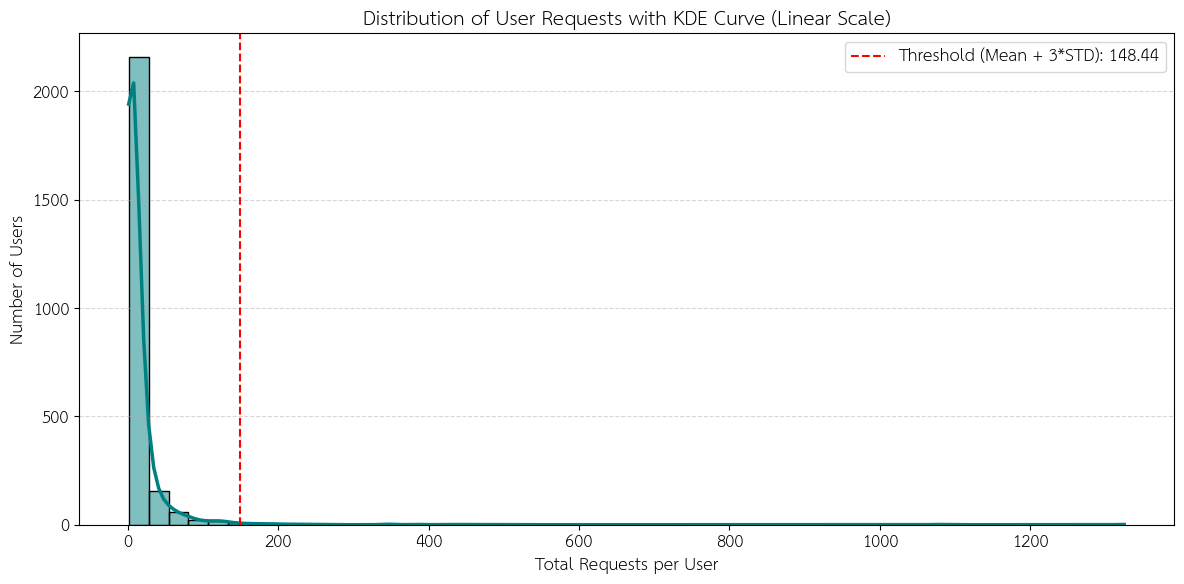

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์และการแสดงผล
plt.figure(figsize=(12, 6))

# สร้างกราฟแจกแจงความถี่ที่มีเส้น KDE (Kernel Density Estimate)
# ใช้ element='step' หรือ default bar และระบุ kde=True
sns.histplot(
    data=user_activity,
    x='Total_Requests',
    bins=50,
    kde=True,
    color='teal',
    edgecolor='black',
    line_kws={'linewidth': 2.5, 'color': 'darkorange'}
)

# เอาพล็อตสเกล Log ออกตามความต้องการของผู้ใช้งาน เพื่อแสดงผลแบบสเกลปกติ (Linear Scale)
# plt.yscale('log')

# วาดเส้นขีดจำกัดความผิดปกติ (Mean + 3*STD)
plt.axvline(threshold_3std, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (Mean + 3*STD): {threshold_3std:.2f}')

# ปรับแต่งรายละเอียดและป้ายกำกับของกราฟ (เปลี่ยนป้ายจาก Log เป็น Normal/Linear Scale)
plt.title('Distribution of User Requests with KDE Curve (Linear Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Total Requests per User', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

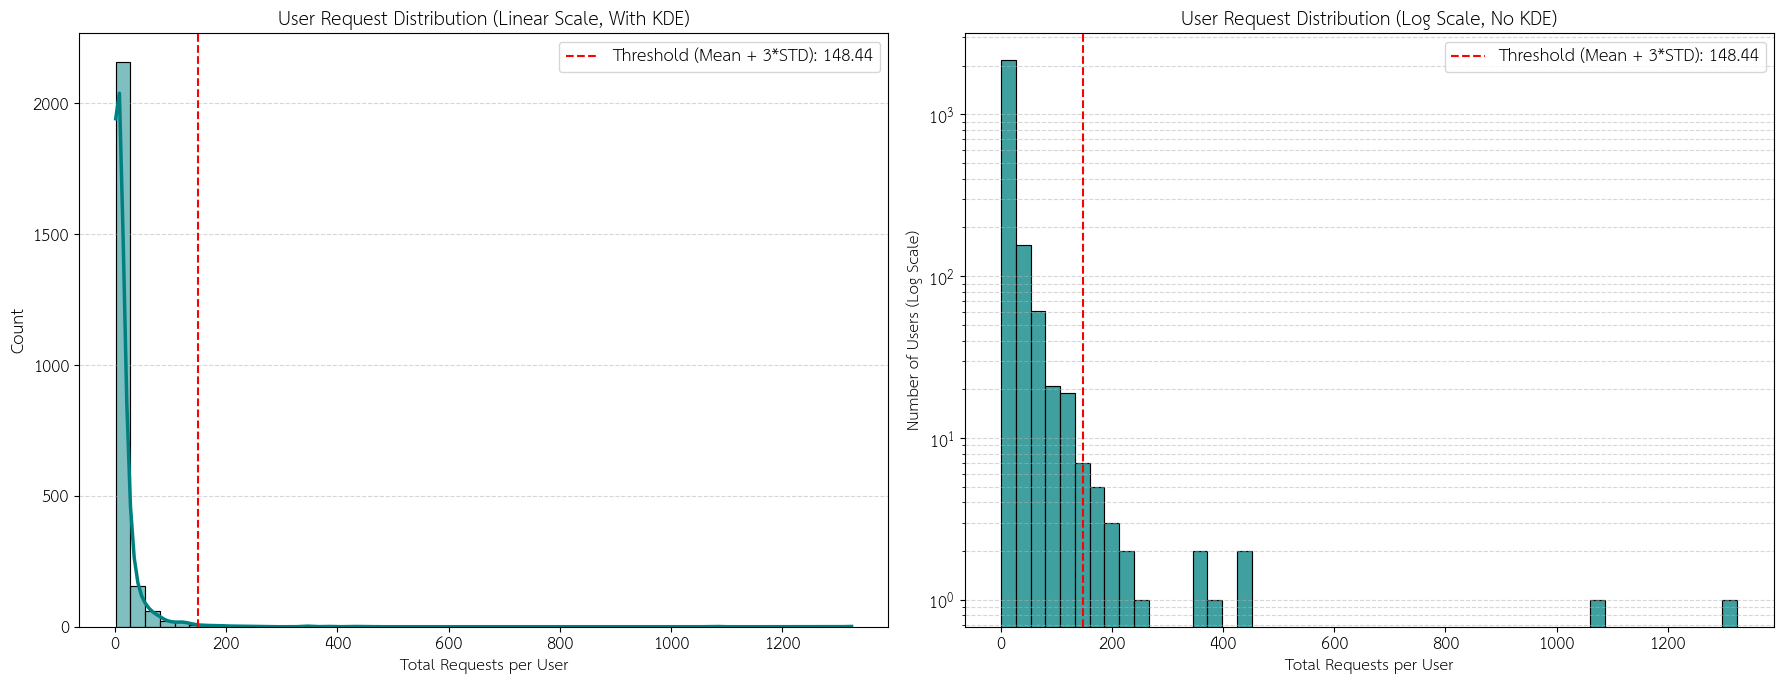

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าขนาดกราฟแบบคู่เคียงข้างกัน (1 แถว, 2 คอลัมน์)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))



# -----------------------------------------------------
# กราฟที่ 1: Linear Scale (มี KDE Curve)
# -----------------------------------------------------
sns.histplot(
    data=user_activity,
    x='Total_Requests',
    bins=50,
    kde=True,   # ใส่ KDE ตามความต้องการ
    color='teal',
    edgecolor='black',
    line_kws={'linewidth': 2.5, 'color': 'darkorange'},
    ax=axes[0]
)
# สเกลเป็น Linear (ไม่มี plt.yscale('log'))
axes[0].axvline(threshold_3std, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (Mean + 3*STD): {threshold_3std:.2f}')
axes[0].set_title('User Request Distribution (Linear Scale, With KDE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Requests per User', fontsize=11)
axes[1].set_ylabel('Number of Users (Linear Scale)', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# -----------------------------------------------------
# กราฟที่ 2: Log Scale (ไม่มี KDE Curve)
# -----------------------------------------------------
sns.histplot(
    data=user_activity,
    x='Total_Requests',
    bins=50,
    kde=False,  # ไม่ใส่ KDE ตามความต้องการ
    color='teal',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_yscale('log')  # ตั้งค่าสเกล Log
axes[1].axvline(threshold_3std, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (Mean + 3*STD): {threshold_3std:.2f}')
axes[1].set_title('User Request Distribution (Log Scale, No KDE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Requests per User', fontsize=11)
axes[1].set_ylabel('Number of Users (Log Scale)', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5, which='both')

plt.tight_layout()
plt.show()